# Section 1: Library Imports and Environment Setup

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
import unicodedata
import json
from scipy import stats as scipy_stats
from scipy import stats
from itertools import combinations
from sklearn.model_selection import GridSearchCV
from data.account_config import ACCOUNT_CATEGORIES
from collections import Counter
from langdetect import detect
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Section 2: Loading the Dataset



In [2]:
df = pd.read_csv("data/raw_posts.csv")

print(f"Posts: {len(df)}")
print(f"Accounts: {df['username'].nunique()}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Missing captions: {df['caption'].isna().sum()}") 


Posts: 2916
Accounts: 120
Columns: ['username', 'followers_count', 'caption', 'like_count', 'comments_count', 'timestamp']
Date range: 2025-05-02T10:00:24+0000 to 2026-05-28T12:02:51+0000
Missing captions: 20


# Section 3: Mapping Account Categories

In [3]:
df['account_category'] = df['username'].map(ACCOUNT_CATEGORIES)

mapped = df['account_category'].notna().sum()
unmapped = df['account_category'].isna().sum()
print(f"  Mapped:   {mapped} posts")
print(f"  Unmapped: {unmapped} posts")
print(f"\nPosts per category:")
print(df['account_category'].value_counts())

if unmapped > 0:
    still_unmapped = df[df['account_category'].isna()]['username'].unique()
    print(f"\nStill unmapped usernames:")
    for u in sorted(still_unmapped):
        print(f"  {u}")

  Mapped:   2916 posts
  Unmapped: 0 posts

Posts per category:
account_category
Government & Public       500
Media & News              499
Creators & Influencers    489
Local Businesses          477
Tourism & Hospitality     477
Sports & Fitness          474
Name: count, dtype: int64


# Section 4: Hashtag Extraction

In [4]:
def extract_hashtags(caption):
    if pd.isna(caption) or caption == "":
        return []
    return re.findall(r'#([^\s#.,!?;:()\[\]{}"\']+)', caption.lower())

df['hashtags'] = df['caption'].apply(extract_hashtags)
df['hashtag_total'] = df['hashtags'].apply(len)

accented = [h for hashtags in df['hashtags'] for h in hashtags
            if any(c in h for c in ['għ', 'ħ', 'ċ', 'ġ', 'ż', 'è', 'à', 'ì', 'ò', 'ù'])]

print(f"Hashtags extracted successfully.")
print(f"Posts with no hashtags:    {(df['hashtag_total'] == 0).sum()}")
print(f"Average hashtags per post: {df['hashtag_total'].mean():.2f}")
print(f"Max hashtags in a post:    {df['hashtag_total'].max()}")
print(f"Hashtags with accented characters: {len(accented)}")

Hashtags extracted successfully.
Posts with no hashtags:    1614
Average hashtags per post: 1.91
Max hashtags in a post:    30
Hashtags with accented characters: 12


# Section 5: UGT Hashtag Classification

## 5.1: Classification Function and Dictionary

In [5]:
def normalise_hashtag(hashtag):
    """Normalise accented Maltese/Italian characters for matching"""
    return unicodedata.normalize('NFKD', hashtag).encode('ascii', 'ignore').decode('ascii').lower().strip()

ugt_dictionary = {

    "informational": [
        # Knowledge, education, news, awareness
        "tutorial", "guide", "tips", "howto", "diy", "learn", "education",
        "info", "news", "update", "announcement", "fact", "knowledge", "mfsa", "mita", "knowbeforeyousign", "gmw2026", "moneymatters",
        "advice", "review", "explained", "course", "lesson", "resource", "study", "research", "report",
        "awareness", "health", "safety", "environment", "sustainability",
        "interview", "documentary", "podcast", "breaking", "latest", "official", "statement", "policy", "regulation",
        "tourismstudies", "matsec", "history", "digital",
        "circulareconomy", "rescueoperation", "searchandrescue",
        "wastesorting", "financialliteracy", "maltadaily", "vibefm", "897bay", "baybreakfast",
        "election", "clickwisely", "projectgreen", "erasmusplus", "freehour", "rtk103",
        # International country/region names - news and media geographic context
        "europe", "international", "china", "russia", "france", "austria",
        "italy", "uk", "germany", "spain", "usa", "america",
        # Maltese language
        "gwida", "taghrif", "ahbarijek", "avviz", "edukazzjoni", "listorja", "nifsġdid",
    ],

    "entertaining": [
        # Humour, lifestyle, food, fashion, fitness, travel, aesthetic
        "fun", "funny", "lol", "meme", "humour", "joke",
        "entertainment", "music", "dance", "art", "creative", "comedy",
        "happy", "joy", "smile", "laugh", "cute", "beautiful", "love",
        "food", "foodie", "recipe", "coffee", "travel", "adventure", "wanderlust",
        "lifestyle", "fashion", "style", "beauty", "makeup", "skincare",
        "fitness", "workout", "gym", "sport", "game", "gaming",
        "movie", "film", "series", "photo", "photography", "nature",
        "sunset", "beach", "sea", "holiday", "party", "festival", "levelup",
        "event", "concert", "culture", "show", "summer", "winter",
        "easter", "carnival", "valentines", "eastertreats",
        "christmas", "christmastime", "mothersday", "focaccia", "crispychicken",
        "burger", "wigs", "outfit", "outfitstyling", "grwm", "pink", "ootd", "shooting", "90s", "uefaeurou21",
        "explore", "exploremore", "architecture", "pilates",
        "reels", "marathon", "sundaylunch",
        "mediterraneanflavours", "mediterraneanvibes", "freshlybaked",
        "haircolor", "mensstyling", "menssuit", "gentleman", "cosyvibes", "wherechampionstrain", "personaltraining",
        "chicken", "cravings", "cheese", "eats",
        "delicious", "fries", "ricottaandbeans", "saucy", "italianpasta", "beyourbest", "trainhard",
        "eurovision", "football", "yoga", "hyrox", "dedication", "noexcuses", "yourlimitsareundefined",
        "manchesterunited", "wellnessjourney", "transformation",
        "coast", "interiordesign", "stpatricksday",
        "isleofmtv", "hannahmontana", "functionalfitness",
        # Maltese language
        "divertiment", "logħob", "ikel", "safar", "arti", "qaghqa", "qassatat", "zeppolata",
        "ftira", "qaghqatalappostli", "muzikamuzika", "figolla", "figolli", "pastizzi",
    ],

    "relational": [
        # Community, belonging, social bonds, team identity
        "community", "family", "friends", "together", "support",
        "maltese", "malteseculture", "locals", "locallife",
        "memories", "throwback", "tbt", "grateful", "blessed",
        "teamwork", "crew", "squad", "tribe", "gang", "ksu",
        "networking", "connect", "collaboration",
        "volunteer", "charity", "nonprofit", "cause", "shineatum",
        "faith", "military", "exiles", "pride", "heritage",
        "discipline", "championmentality", "consistency", "strongereveryday",
        "motivation", "power", "qotd", "behindthescenes",
        "momlife", "mumlife", "mums", "lifeofmum", "lifeofmumd",
        "pregnancyjourney", "secondtrimester", "makingmoments", "wearewasteserv", "campuslife", "mcast",
        "vallettafc", "womensfootball", "afm",
        "studentlife", "strengthtosucceed", "ichooseexcellence", "weareits",
        "visitmalta", "visitgozo", "lovemalta", "bovchallengecup", "yohealthmaltapremier",
        "armedforcesofmalta_afm", "hamrunspartans", "maltapolice",
        "somethingforeveryone", "trainwithchampions",
        "workersday", "maltamilitarygames", "mmg2026", "meettheteam",
        "capital", "capitalcity", "islandlife", "island", "mediterranean",
        "klabb316", "medevac",
        # Maltese place names - community identity and local belonging
        # Brockdorff et al. (2013) Maltese users primarily motivated by networking and social connection
        "malta", "gozo", "valletta", "sliema", "stjulians",
        "mellieha", "marsaxlokk", "mdina", "rabat", "mosta", "naxxar",
        "birkirkara", "zebbug", "qormi", "hamrun", "gzira", "msida",
        "birgu", "vittoriosa", "cospicua", "bugibba", "pembroke", "luqa",
        "attard", "balzan", "lija", "iklin", "swieqi",
        "marsaskala", "zurrieq", "siggiewi", "kirkop", "safi", "ghaxaq",
        "tarxien", "paola", "fgura", "zabbar", "zejtun", "ghajnsielem",
        "victoria", "xaghra", "xewkija", "nadur", "kercem", "munxar",
        "floriana", "pieta", "gwardamangia", "sanlawrenz",
        "comino", "filfla", "sangwann", "stpaulsbay",
        "flimkien", "komunita", "familja", "hbieb", "maltin", "bizzilla",
    ],

    "remunerative": [
        # Commercial, promotional, business, hiring
        "giveaway", "win", "discount", "offer", "promo", "sale",
        "deal", "free", "competition", "contest", "prize",
        "brand", "sponsored", "ad", "collab", "partnership",
        "shop", "buy", "order", "booking", "available", "instock",
        "new", "launch", "product", "service", "business",
        "hiring", "job", "career", "recruitment", "apply",
        "marketing", "hospitality", "agency", "entrepreneur",
        "careerinhospitalityandtourism", "vacancy", "applynow",
        "limitedtimeonly", "award",
        "newissue", "tunein", "listenlive",
        "giftsformum", "giftformum", "takeaway", "bakery", "bakedgoodness",
        "guestexperience", "comingsoon", "staytuned", "yourdestination", "staywithus",
        "watchnow", "beboldbeyou", "hobzatafrans", "fransilhammalu", "opening", "innovation",
        # Maltese language
        "xogħol", "negozju", "servizz", "offerta",
    ],
}


maltese_brands_remunerative = [
    # Hotels
    "corinthia", "corinthiapalace", "kempinski", "hoteltacenc", "tacencexperience",
    "hiltonforthestay", "tasteofhilton", "wearehiltonwearehospitality",
    "hiltonmalta", "kempinskigozo", "thephoeniciamalta", "grandhotelexcelsior",
    "ramlabayresort", "mercury", "westinmalta", "axodycy",
    "preferredhotels", "thepreferredlife", "serandipians", "westindragonara",
    # Food and beverage
    "panina", "paninamalta", "panineria", "bulubeef", "sphinxpastizzeria", "cafejubilee",
    "welbees", "toronerosteaklounge", "loa", "contessarestaurant", "lortolan",
    "maypole", "southernfriedchicken", "sfc", "farsonsdirect", "busybee",
    "southernsauce", "shack", "bitecrunchrepeat", "dipcrunchrepeat",
    # Fitness and wellness
    "cynergi", "fortfitness", "crossfit356",
    # Other Maltese brands
    "mvintage", "secretgarden", "arzella",
]

def classify_hashtag(hashtag):
    """
    Classifies a single hashtag into one UGT category.
    Layer 1a: Exact match in UGT dictionary
    Layer 2a: Exact match in Maltese brand list (remunerative)
    Layer 2b: Substring match in Maltese brand list (remunerative)
    Layer 1b: Generic substring match (lowest priority)
    Returns 'unclassified' if no match found.
    """
    hashtag_raw = hashtag.lower().strip()
    hashtag_norm = normalise_hashtag(hashtag_raw)

    # Layer 1a - exact match
    for category, keywords in ugt_dictionary.items():
        norm_keywords = [normalise_hashtag(k) for k in keywords]
        if hashtag_norm in norm_keywords or hashtag_raw in keywords:
            return category

    # Layer 2a - Maltese brand exact match
    if hashtag_norm in [normalise_hashtag(b) for b in maltese_brands_remunerative]:
        return "remunerative"

    # Layer 2b — Maltese brand substring match
    for brand in maltese_brands_remunerative:
        if normalise_hashtag(brand) in hashtag_norm:
            return "remunerative"

    # Layer 1b — generic substring match (lowest priority)
    for category, keywords in ugt_dictionary.items():
        for keyword in keywords:
            if normalise_hashtag(keyword) in hashtag_norm:
                return category

    return "unclassified"

def classify_post_hashtags(hashtag_list):
    """Classifies all hashtags in a post and returns category counts."""
    counts = {
        "informational_count": 0, "entertaining_count": 0,
        "relational_count": 0, "remunerative_count": 0, "unclassified_count": 0
    }
    for hashtag in hashtag_list:
        category = classify_hashtag(hashtag)
        counts[f"{category}_count"] += 1
    return counts

# Apply classification to dataset
classification_results = df['hashtags'].apply(classify_post_hashtags)
classification_df = pd.DataFrame(classification_results.tolist())
for col in classification_df.columns:
    df[col] = classification_df[col]

total_hashtags = df['hashtag_total'].sum()
classified = total_hashtags - df['unclassified_count'].sum()
rate = (classified / total_hashtags * 100) if total_hashtags > 0 else 0

print("Classification complete.")
print(f"Total hashtags: {int(total_hashtags)}")
print(f"Classified:     {int(classified)} ({rate:.1f}%)")
print(f"Unclassified:   {int(df['unclassified_count'].sum())} ({100-rate:.1f}%)")
print(f"\nCategory totals:")
print(f"  Informational:  {int(df['informational_count'].sum())}")
print(f"  Entertaining:   {int(df['entertaining_count'].sum())}")
print(f"  Relational:     {int(df['relational_count'].sum())}")
print(f"  Remunerative:   {int(df['remunerative_count'].sum())}")

Classification complete.
Total hashtags: 5573
Classified:     4245 (76.2%)
Unclassified:   1328 (23.8%)

Category totals:
  Informational:  426
  Entertaining:   1266
  Relational:     1516
  Remunerative:   1037


## 5.2: Unclassified Hashtag Inspection

In [6]:
unclassified_hashtags = [
    h for hashtag_list, counts in zip(df['hashtags'], df['unclassified_count'].values)
    if counts > 0
    for h in hashtag_list
    if classify_hashtag(h) == 'unclassified'
]

top_unclassified = Counter(unclassified_hashtags).most_common(20)

print("TOP 20 UNCLASSIFIED HASHTAGS")
for hashtag, count in top_unclassified:
    print(f"  #{hashtag:<30} {count:>4} occurrences")

print(f"\nTotal unique unclassified hashtags: {len(set(unclassified_hashtags))}")
print(f"Total unclassified occurrences:     {len(unclassified_hashtags)}")

TOP 20 UNCLASSIFIED HASHTAGS
  #picoftheday                      12 occurrences
  #onebreakfast                      9 occurrences
  #bgm                               9 occurrences
  #sweetmoments                      8 occurrences
  #instapic                          8 occurrences
  #feedbackfriday                    5 occurrences
  #spring                            4 occurrences
  #cosplay                           4 occurrences
  #highproteinmeals                  4 occurrences
  #mt                                4 occurrences
  #sundayvibes                       4 occurrences
  #sar                               4 occurrences
  #meridianbetfatrophy               4 occurrences
  #weee                              4 occurrences
  #wastemanagement                   4 occurrences
  #againstallodds                    4 occurrences
  #reformerstudio                    4 occurrences
  #bob                               3 occurrences
  #haircut                           3 occurrences
  

# Section 6: Hashtag-Level Charactertistics

In [7]:


# Characteristic 2: Average hashtag character length
def avg_hashtag_length(hashtag_list):
    if len(hashtag_list) == 0:
        return 0
    return sum(len(h) for h in hashtag_list) / len(hashtag_list)

df['avg_hashtag_length'] = df['hashtags'].apply(avg_hashtag_length)

# Characteristic 3: Hashtag language detection
# A hashtag is classified as Maltese if it:
# 1. Exactly matches a known Maltese word from the UGT dictionary
# 2. Contains distinctly Maltese character patterns (għ, ħ, ċ, ġ, ż)
# All other hashtags default to English
# Note: langdetect is unreliable on single words so dictionary matching is used as the primary method, supported by Maltese character detection

# Build Maltese keyword set from dictionary Maltese sections only
maltese_keywords = set()

# Maltese words from informational
for word in ["gwida", "taghrif", "ahbarijiet", "avviz", "edukazzjoni", "listorja"]:
    maltese_keywords.add(normalise_hashtag(word))

# Maltese words from entertaining
for word in ["divertiment", "logħob", "ikel", "safar", "arti"]:
    maltese_keywords.add(normalise_hashtag(word))

# Maltese words from relational
for word in ["flimkien", "komunita", "familja", "hbieb", "maltin"]:
    maltese_keywords.add(normalise_hashtag(word))

# Maltese words from remunerative
for word in ["xogħol", "negozju", "servizz", "offerta"]:
    maltese_keywords.add(normalise_hashtag(word))

# Maltese place names — in relational category, also Maltese language identifiers
maltese_place_names = [
    "malta", "gozo", "valletta", "sliema", "stjulians",
    "mellieha", "marsaxlokk", "mdina", "rabat", "mosta", "naxxar",
    "birkirkara", "zebbug", "qormi", "hamrun", "gzira", "msida",
    "birgu", "vittoriosa", "cospicua", "bugibba", "pembroke", "luqa",
    "attard", "balzan", "lija", "iklin", "swieqi", "sanawla",
    "marsaskala", "zurrieq", "siggiewi", "kirkop", "safi", "ghaxaq",
    "tarxien", "paola", "fgura", "zabbar", "zejtun", "ghajnsielem",
    "victoria", "xaghra", "xewkija", "nadur", "kercem", "munxar",
    "floriana", "pieta", "gwardamangia", "sanlawrenz",
    "comino", "filfla", "maltese", "malteseculture", "maltin",
]
for word in maltese_place_names:
    maltese_keywords.add(normalise_hashtag(word))

# Maltese character patterns — distinctly Maltese letters
MALTESE_CHARS = set('ħġżċ')
MALTESE_DIGRAPHS = ['għ']

def classify_hashtag_language(hashtag):
    """
    Classifies a hashtag as Maltese or English.
    Method 1: Dictionary exact match
    Method 2: Maltese character pattern detection
    Default: English
    """
    norm = normalise_hashtag(hashtag)
    raw = hashtag.lower().strip()

    # Method 1: exact match against Maltese keyword set
    if norm in maltese_keywords:
        return 'maltese'

    # Method 2: contains distinctly Maltese characters
    if any(c in raw for c in MALTESE_CHARS):
        return 'maltese'

    # Method 3: contains Maltese digraphs
    if any(d in raw for d in MALTESE_DIGRAPHS):
        return 'maltese'

    return 'english'

def post_language_counts(hashtag_list):
    english = sum(1 for h in hashtag_list if classify_hashtag_language(h) == 'english')
    maltese = sum(1 for h in hashtag_list if classify_hashtag_language(h) == 'maltese')
    return english, maltese

lang_results = df['hashtags'].apply(post_language_counts)
df['hashtag_english_count'] = lang_results.apply(lambda x: x[0])
df['hashtag_maltese_count']  = lang_results.apply(lambda x: x[1])
df['hashtag_maltese_ratio']  = df.apply(
    lambda row: row['hashtag_maltese_count'] / row['hashtag_total']
    if row['hashtag_total'] > 0 else 0, axis=1
)


print("Hashtag-level characteristics computed.")
print(f"\nCharacteristic 1 — Number of hashtags per post:")
print(f"  Mean: {df['hashtag_total'].mean():.2f}")
print(f"  Max:  {df['hashtag_total'].max()}")
print(f"  Posts with no hashtags: {(df['hashtag_total'] == 0).sum()}")

print(f"\nCharacteristic 2 — Average hashtag character length:")
print(f"  Mean (posts with hashtags): {df[df['hashtag_total'] > 0]['avg_hashtag_length'].mean():.2f} characters")
print(f"  Max:  {df['avg_hashtag_length'].max():.2f} characters")

print(f"\nCharacteristic 3 — Hashtag language split:")
total_ht = df['hashtag_total'].sum()
total_mt = df['hashtag_maltese_count'].sum()
total_en = df['hashtag_english_count'].sum()
print(f"  English hashtags: {int(total_en)} ({total_en/total_ht*100:.1f}%)")
print(f"  Maltese hashtags: {int(total_mt)} ({total_mt/total_ht*100:.1f}%)")
print(f"  Mean Maltese ratio per post: {df['hashtag_maltese_ratio'].mean():.3f}")

print(f"\nCharacteristic 4 — Hashtag UGT category:")
print(f"  Informational:  {int(df['informational_count'].sum())}")
print(f"  Entertaining:   {int(df['entertaining_count'].sum())}")
print(f"  Relational:     {int(df['relational_count'].sum())}")
print(f"  Remunerative:   {int(df['remunerative_count'].sum())}")

Hashtag-level characteristics computed.

Characteristic 1 — Number of hashtags per post:
  Mean: 1.91
  Max:  30
  Posts with no hashtags: 1614

Characteristic 2 — Average hashtag character length:
  Mean (posts with hashtags): 10.66 characters
  Max:  22.00 characters

Characteristic 3 — Hashtag language split:
  English hashtags: 5128 (92.0%)
  Maltese hashtags: 445 (8.0%)
  Mean Maltese ratio per post: 0.033

Characteristic 4 — Hashtag UGT category:
  Informational:  426
  Entertaining:   1266
  Relational:     1516
  Remunerative:   1037


# Section 7: Feature Engineering


In [8]:


# Sentiment analyser initialisation 
analyser = SentimentIntensityAnalyzer()

#  Unique hashtag ratio 
# Measures diversity of hashtag vocabulary per post
# Justified: Gorrepati (2020) — hashtag diversity as engagement signal
def unique_hashtag_ratio(hashtag_list):
    if len(hashtag_list) == 0:
        return 0
    return len(set(hashtag_list)) / len(hashtag_list)

#  Emoji count 
# Captures expressive emotional signalling in captions
# Justified: Gorrepati (2020) — emoji density linked to entertaining content
def count_emojis(text):
    if pd.isna(text):
        return 0
    return len([c for c in str(text) if c in emoji.EMOJI_DATA])

# Sentiment polarity 
# VADER applied to English captions only
# Maltese captions assigned neutral score 0.0
# Language detection using langdetect before scoring
# Justified: Gorrepati (2020) — sentiment as engagement predictor
def get_sentiment(text):
    if pd.isna(text) or str(text).strip() == "":
        return 0.0
    try:
        lang = detect(str(text))
        if lang == 'en':
            score = analyser.polarity_scores(str(text))
            return score['compound']
        else:
            return 0.0
    except:
        return 0.0
    
#  Comment-to-like ratio 
# Operationalises the Relational UGT pillar as a behavioural proxy
# Captures the proportion of users moving beyond passive liking to active reciprocal exchange through commenting, a deeper engagement manifestation
# Justified: Dolan (2015) social interaction dimension; Peters et al. (2013)
# Van Doorn et al. (2010) — observable behavioural manifestation of belonging
# Proxy logic: as argued in Section 2.2.1, comment-to-like ratio directly operationalises relational gratification through measurable behaviour
# Posts with 0 likes assigned 0 to avoid division by zero
df['comment_to_like_ratio'] = df.apply(
    lambda row: row['comments_count'] / row['like_count']
    if row['like_count'] > 0 else 0, axis=1
)   


# Apply features 
df['unique_hashtag_ratio'] = df['hashtags'].apply(unique_hashtag_ratio)
df['caption_length'] = df['caption'].apply(
    lambda x: len(str(x)) if pd.notna(x) else 0)
df['emoji_count'] = df['caption'].apply(count_emojis)
df['sentiment_polarity'] = df['caption'].apply(get_sentiment)

# Full feature set summary 
print("Feature engineering complete.")
print(f"\nUGT hashtag purpose features:")
print(f"  informational_count:  {df['informational_count'].mean():.3f} mean")
print(f"  entertaining_count:   {df['entertaining_count'].mean():.3f} mean")
print(f"  relational_count:     {df['relational_count'].mean():.3f} mean")
print(f"  remunerative_count:   {df['remunerative_count'].mean():.3f} mean")
print(f"\nStructural hashtag features:")
print(f"  hashtag_total:        {df['hashtag_total'].mean():.3f} mean")
print(f"  unique_hashtag_ratio: {df['unique_hashtag_ratio'].mean():.3f} mean")
posts_with_hashtags = df[df['hashtag_total'] > 0]
print(f"  avg_hashtag_length:   {posts_with_hashtags['avg_hashtag_length'].mean():.3f} mean (posts with hashtags only)")
print(f"  hashtag_maltese_ratio:{df['hashtag_maltese_ratio'].mean():.3f} mean")
print(f"\nCaption features:")
print(f"  caption_length:       {df['caption_length'].mean():.1f} mean chars")
print(f"  emoji_count:          {df['emoji_count'].mean():.2f} mean")
print(f"  sentiment_polarity:   {df['sentiment_polarity'].mean():.3f} mean")
print(f"  comment_to_like_ratio: {df['comment_to_like_ratio'].mean():.3f} mean")

Feature engineering complete.

UGT hashtag purpose features:
  informational_count:  0.146 mean
  entertaining_count:   0.434 mean
  relational_count:     0.520 mean
  remunerative_count:   0.356 mean

Structural hashtag features:
  hashtag_total:        1.911 mean
  unique_hashtag_ratio: 0.446 mean
  avg_hashtag_length:   10.656 mean (posts with hashtags only)
  hashtag_maltese_ratio:0.033 mean

Caption features:
  caption_length:       324.5 mean chars
  emoji_count:          2.20 mean
  sentiment_polarity:   0.492 mean
  comment_to_like_ratio: 0.034 mean


# Section 8: Engagement Rate Calculation

In [9]:
# Section 5: Engagement Rate Calculation and Classification 
# Engagement rate formula: (0.4 * likes + 0.6 * comments) / followers * 100
# Weighted formula justified by Gorrepati (2020) — comments require greater
# cognitive effort than likes and represent deeper engagement behaviour
# (Peters et al., 2013; Van Doorn et al., 2010)

# Calculate engagement rate 
df['engagement_rate'] = (
    (0.4 * df['like_count'] + 0.6 * df['comments_count']) / df['followers_count']
) * 100

# Remove posts with zero followers 
df = df[df['followers_count'] > 0].copy()

#  Remove extreme outliers 
before = len(df)
df = df[df['engagement_rate'] <= 100].copy()
after = len(df)

# Binary classification using median split
# Two classes: Low and High
# Split at median to ensure balanced classes and meaningful separation
# Binary classification selected because narrow engagement rate distribution
# makes three-class separation unreliable (Crowe, 2018)
# Focuses analysis on fundamental distinction between low and high performing content

median_threshold = df['engagement_rate'].median()

def classify_engagement(rate):
    if rate <= median_threshold:
        return 'Low'
    else:
        return 'High'

df['engagement_level'] = df['engagement_rate'].apply(classify_engagement)

print(f"Engagement calculation complete.")
print(f"Outliers removed: {before - after} posts")
print(f"Remaining posts:  {after}")
print(f"\nEngagement rate statistics:")
print(f"  Mean:   {df['engagement_rate'].mean():.3f}%")
print(f"  Median: {df['engagement_rate'].median():.3f}%")
print(f"  Max:    {df['engagement_rate'].max():.3f}%")
print(f"\nMedian threshold: {median_threshold:.4f}%")
print(f"\nEngagement level distribution:")
print(df['engagement_level'].value_counts())
print(f"\nEngagement level percentages:")
print(df['engagement_level'].value_counts(normalize=True).mul(100).round(1))

Engagement calculation complete.
Outliers removed: 0 posts
Remaining posts:  2916

Engagement rate statistics:
  Mean:   0.344%
  Median: 0.107%
  Max:    39.015%

Median threshold: 0.1074%

Engagement level distribution:
engagement_level
Low     1458
High    1458
Name: count, dtype: int64

Engagement level percentages:
engagement_level
Low     50.0
High    50.0
Name: proportion, dtype: float64


In [10]:
# Engagement Weight Sensitivity Check 
# Verifies that the weighted formula (0.4 likes, 0.6 comments) does not
# produce materially different conclusions vs alternative weighting schemes
# Justified: Peters et al. (2013) — comment weighting is a methodological
# choice that should be tested for robustness

df['er_equal']     = ((0.5 * df['like_count'] + 0.5 * df['comments_count']) / df['followers_count']) * 100
df['er_likes_only'] = (df['like_count'] / df['followers_count']) * 100

median_equal      = df['er_equal'].median()
median_likes_only = df['er_likes_only'].median()

df['level_equal']      = df['er_equal'].apply(lambda x: 'High' if x > median_equal else 'Low')
df['level_likes_only'] = df['er_likes_only'].apply(lambda x: 'High' if x > median_likes_only else 'Low')

agreement_equal      = (df['engagement_level'] == df['level_equal']).mean() * 100
agreement_likes_only = (df['engagement_level'] == df['level_likes_only']).mean() * 100

print("ENGAGEMENT WEIGHT SENSITIVITY CHECK")
print(f"  Primary formula   (0.4L + 0.6C): median = {df['engagement_rate'].median():.4f}%")
print(f"  Equal weights     (0.5L + 0.5C): median = {median_equal:.4f}%")
print(f"  Likes only        (1.0L + 0.0C): median = {median_likes_only:.4f}%")
print(f"\n  Agreement with primary classification:")
print(f"    Equal weights:  {agreement_equal:.1f}% of posts classified the same")
print(f"    Likes only:     {agreement_likes_only:.1f}% of posts classified the same")

if agreement_equal >= 85 and agreement_likes_only >= 85:
    print(f"\n  Result: ROBUST — classification is stable across weighting schemes")
else:
    print(f"\n  Result: SENSITIVE — weighting choice materially affects classification")

# Clean up temporary columns
df.drop(columns=['er_equal', 'er_likes_only', 'level_equal', 'level_likes_only'], inplace=True)

ENGAGEMENT WEIGHT SENSITIVITY CHECK
  Primary formula   (0.4L + 0.6C): median = 0.1074%
  Equal weights     (0.5L + 0.5C): median = 0.1336%
  Likes only        (1.0L + 0.0C): median = 0.2612%

  Agreement with primary classification:
    Equal weights:  99.7% of posts classified the same
    Likes only:     98.8% of posts classified the same

  Result: ROBUST — classification is stable across weighting schemes


# Section 9: Exploratory Data Analysis

## Section 9.1: EDA visualisations

/var/folders/ss/mjn0vqjn5k7f78h41y90sqrw0000gn/T/ipykernel_16993/2870220733.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups_lang, labels=['Low', 'High'],
/var/folders/ss/mjn0vqjn5k7f78h41y90sqrw0000gn/T/ipykernel_16993/2870220733.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['Low', 'High'],
/var/folders/ss/mjn0vqjn5k7f78h41y90sqrw0000gn/T/ipykernel_16993/2870220733.py:140: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups_len, labels=['Low', 'High'],


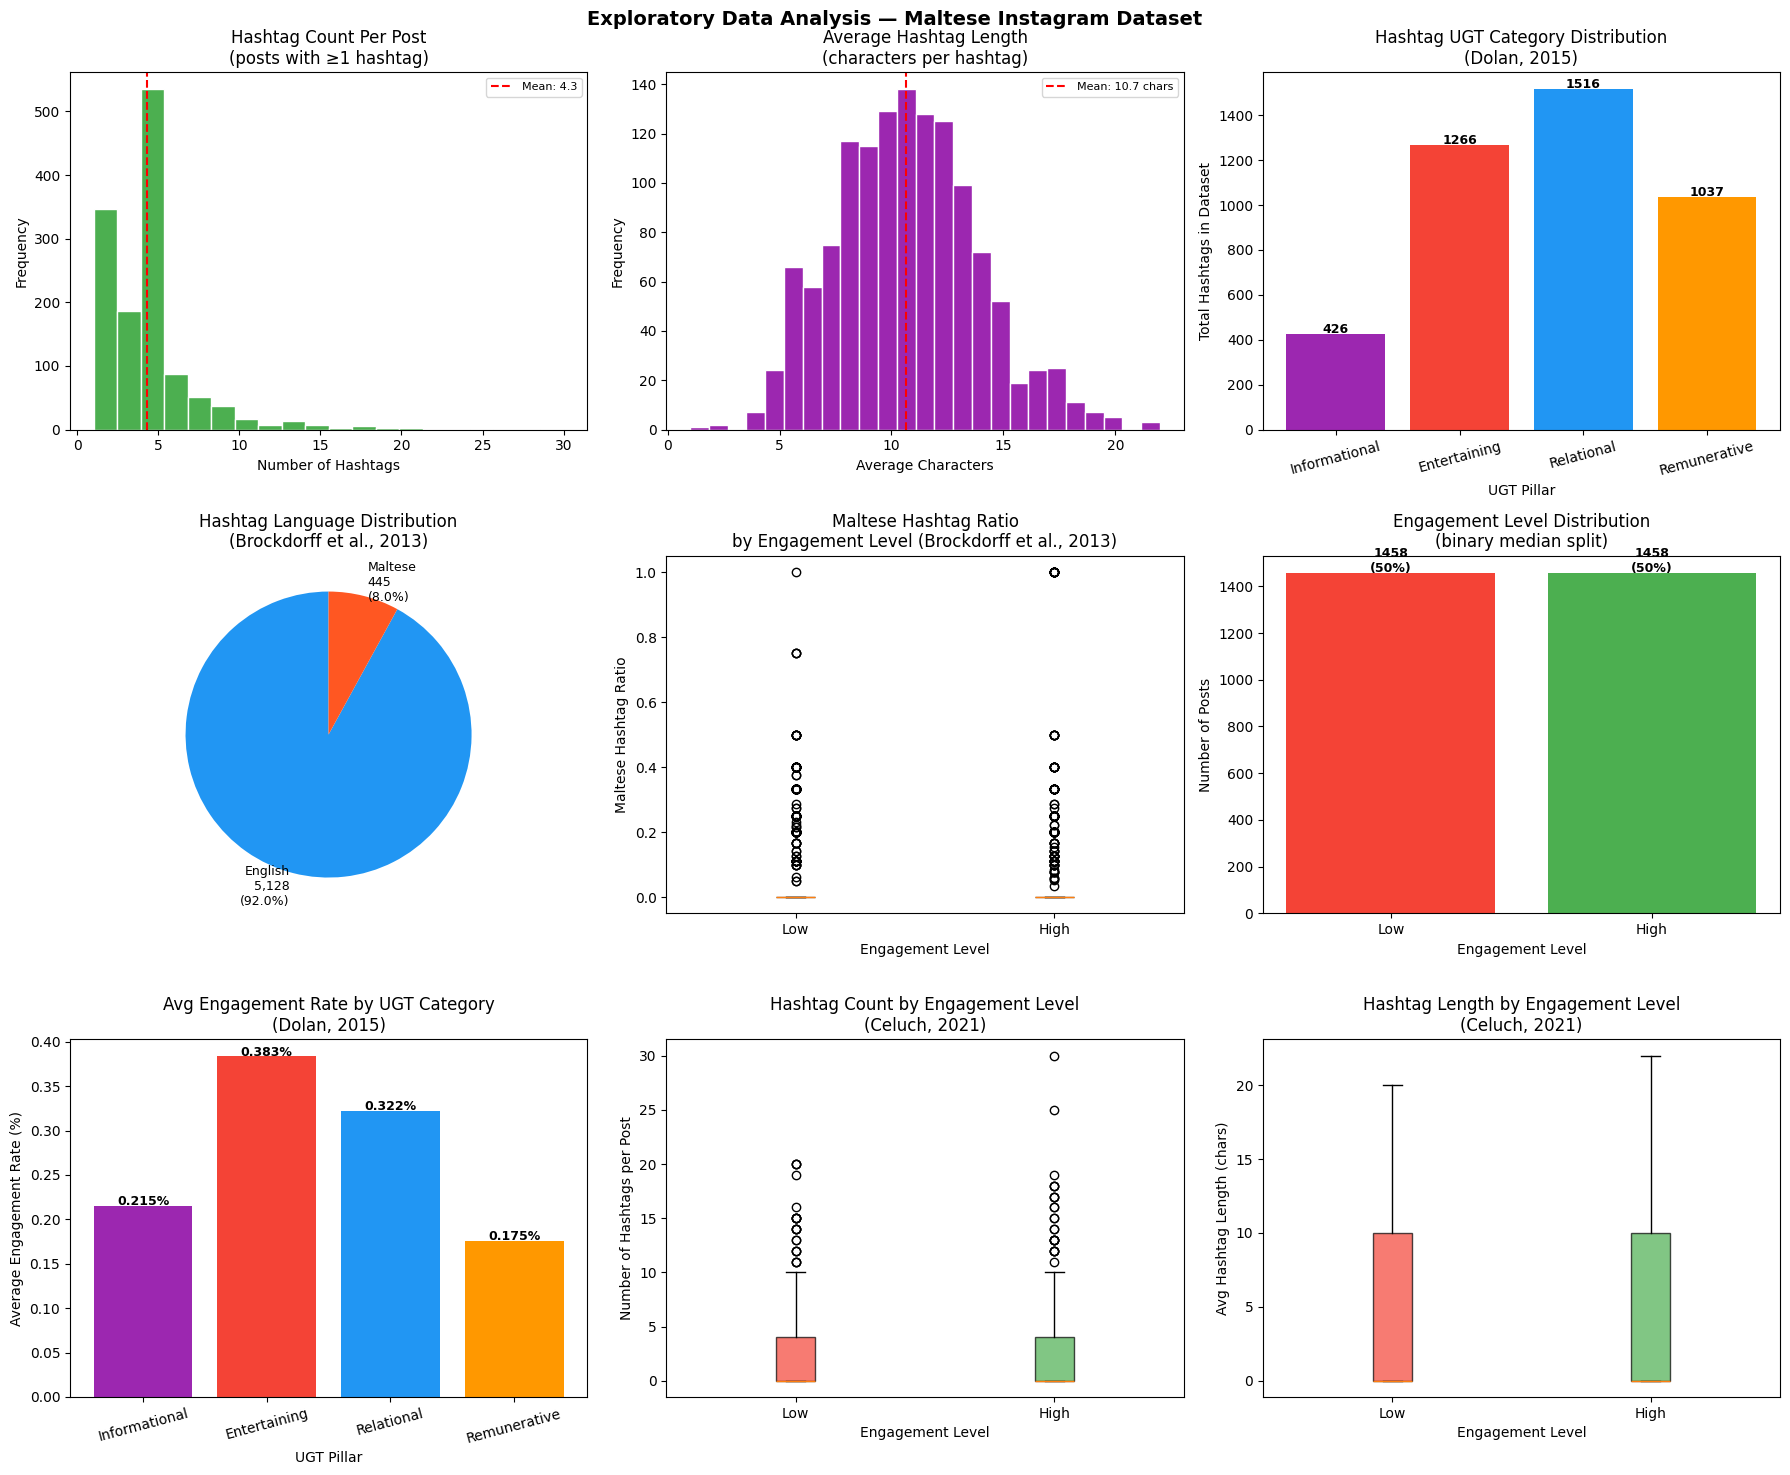

EDA plots saved to outputs/eda_plots.png


In [11]:

# Focused on the 4 hashtag characteristics + engagement outcomes
# Binary classification: Low vs High engagement (median split)


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Exploratory Data Analysis — Maltese Instagram Dataset',
             fontsize=14, fontweight='bold')

# CHARACTERISTIC 1: Hashtag Quantity 
# Celuch (2021): hashtag count correlates with engagement
ax = axes[0, 0]
has_tags = df[df['hashtag_total'] > 0]['hashtag_total']
ax.hist(has_tags, bins=20, color='#4CAF50', edgecolor='white')
ax.axvline(has_tags.mean(), color='red', linestyle='--',
           label=f"Mean: {has_tags.mean():.1f}")
ax.set_title('Hashtag Count Per Post\n(posts with ≥1 hashtag)')
ax.set_xlabel('Number of Hashtags')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

# CHARACTERISTIC 2: Hashtag Character Length 
# Celuch (2021): hashtag length negatively impacts engagement
ax = axes[0, 1]
has_tags_df = df[df['hashtag_total'] > 0]
ax.hist(has_tags_df['avg_hashtag_length'], bins=25,
        color='#9C27B0', edgecolor='white')
ax.axvline(has_tags_df['avg_hashtag_length'].mean(), color='red',
           linestyle='--',
           label=f"Mean: {has_tags_df['avg_hashtag_length'].mean():.1f} chars")
ax.set_title('Average Hashtag Length\n(characters per hashtag)')
ax.set_xlabel('Average Characters')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

# CHARACTERISTIC 3: UGT Category Distribution 
# Dolan (2015): four UGT pillars
ax = axes[0, 2]
categories = ['Informational', 'Entertaining', 'Relational', 'Remunerative']
totals = [
    df['informational_count'].sum(), df['entertaining_count'].sum(),
    df['relational_count'].sum(),    df['remunerative_count'].sum()
]
bars = ax.bar(categories, totals,
              color=['#9C27B0', '#F44336', '#2196F3', '#FF9800'])
ax.set_title('Hashtag UGT Category Distribution\n(Dolan, 2015)')
ax.set_xlabel('UGT Pillar')
ax.set_ylabel('Total Hashtags in Dataset')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(val)), ha='center', fontweight='bold', fontsize=9)

# CHARACTERISTIC 4: Language Distribution 
# Brockdorff et al. (2013): Maltese bilingual digital communication
ax = axes[1, 0]
lang_counts = [df['hashtag_english_count'].sum(), df['hashtag_maltese_count'].sum()]
total_lang = sum(lang_counts)
lang_labels = [
    f'English\n{lang_counts[0]:,}\n({lang_counts[0]/total_lang*100:.1f}%)',
    f'Maltese\n{lang_counts[1]:,}\n({lang_counts[1]/total_lang*100:.1f}%)'
]
ax.pie(lang_counts, labels=lang_labels,
       colors=['#2196F3', '#FF5722'],
       startangle=90, textprops={'fontsize': 9})
ax.set_title('Hashtag Language Distribution\n(Brockdorff et al., 2013)')

# CHARACTERISTIC 4b: Maltese Ratio by Engagement Level 
# Brockdorff et al. (2013): does language choice affect engagement?
ax = axes[1, 1]
groups_lang = [
    df[df['engagement_level'] == 'Low']['hashtag_maltese_ratio'].values,
    df[df['engagement_level'] == 'High']['hashtag_maltese_ratio'].values
]
colors_box = ['#F44336', '#4CAF50']
bp = ax.boxplot(groups_lang, labels=['Low', 'High'],
                patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Maltese Hashtag Ratio\nby Engagement Level (Brockdorff et al., 2013)')
ax.set_xlabel('Engagement Level')
ax.set_ylabel('Maltese Hashtag Ratio')

# ENGAGEMENT 1: Class Distribution 
# Binary classification: Low vs High using median split
ax = axes[1, 2]
counts = df['engagement_level'].value_counts().reindex(['Low', 'High'])
bars = ax.bar(counts.index, counts.values,
              color=['#F44336', '#4CAF50'])
ax.set_title('Engagement Level Distribution\n(binary median split)')
ax.set_xlabel('Engagement Level')
ax.set_ylabel('Number of Posts')
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val}\n({pct:.0f}%)', ha='center', fontweight='bold', fontsize=9)

# ENGAGEMENT 2: Avg Engagement Rate by UGT Category 
# Dolan (2015): which UGT pillar associates most with engagement?
ax = axes[2, 0]
avg_eng = {
    'Informational': df[df['informational_count'] > 0]['engagement_rate'].mean(),
    'Entertaining':  df[df['entertaining_count']  > 0]['engagement_rate'].mean(),
    'Relational':    df[df['relational_count']    > 0]['engagement_rate'].mean(),
    'Remunerative':  df[df['remunerative_count']  > 0]['engagement_rate'].mean()
}
bars = ax.bar(avg_eng.keys(), avg_eng.values(),
              color=['#9C27B0', '#F44336', '#2196F3', '#FF9800'])
ax.set_title('Avg Engagement Rate by UGT Category\n(Dolan, 2015)')
ax.set_xlabel('UGT Pillar')
ax.set_ylabel('Average Engagement Rate (%)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, avg_eng.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}%', ha='center', fontweight='bold', fontsize=9)

# ENGAGEMENT 3: Hashtag Count by Engagement Level
# Celuch (2021): do posts with more hashtags get more engagement?
ax = axes[2, 1]
groups = [
    df[df['engagement_level'] == 'Low']['hashtag_total'].values,
    df[df['engagement_level'] == 'High']['hashtag_total'].values
]
bp = ax.boxplot(groups, labels=['Low', 'High'],
                patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Hashtag Count by Engagement Level\n(Celuch, 2021)')
ax.set_xlabel('Engagement Level')
ax.set_ylabel('Number of Hashtags per Post')

# ENGAGEMENT 4: Hashtag Length by Engagement Level
# Celuch (2021): does shorter hashtag length associate with higher engagement?
ax = axes[2, 2]
groups_len = [
    df[df['engagement_level'] == 'Low']['avg_hashtag_length'].values,
    df[df['engagement_level'] == 'High']['avg_hashtag_length'].values
]
bp = ax.boxplot(groups_len, labels=['Low', 'High'],
                patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Hashtag Length by Engagement Level\n(Celuch, 2021)')
ax.set_xlabel('Engagement Level')
ax.set_ylabel('Avg Hashtag Length (chars)')

plt.tight_layout()
plt.savefig('outputs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved to outputs/eda_plots.png")

## Section 9.2: Correlation Heatmap

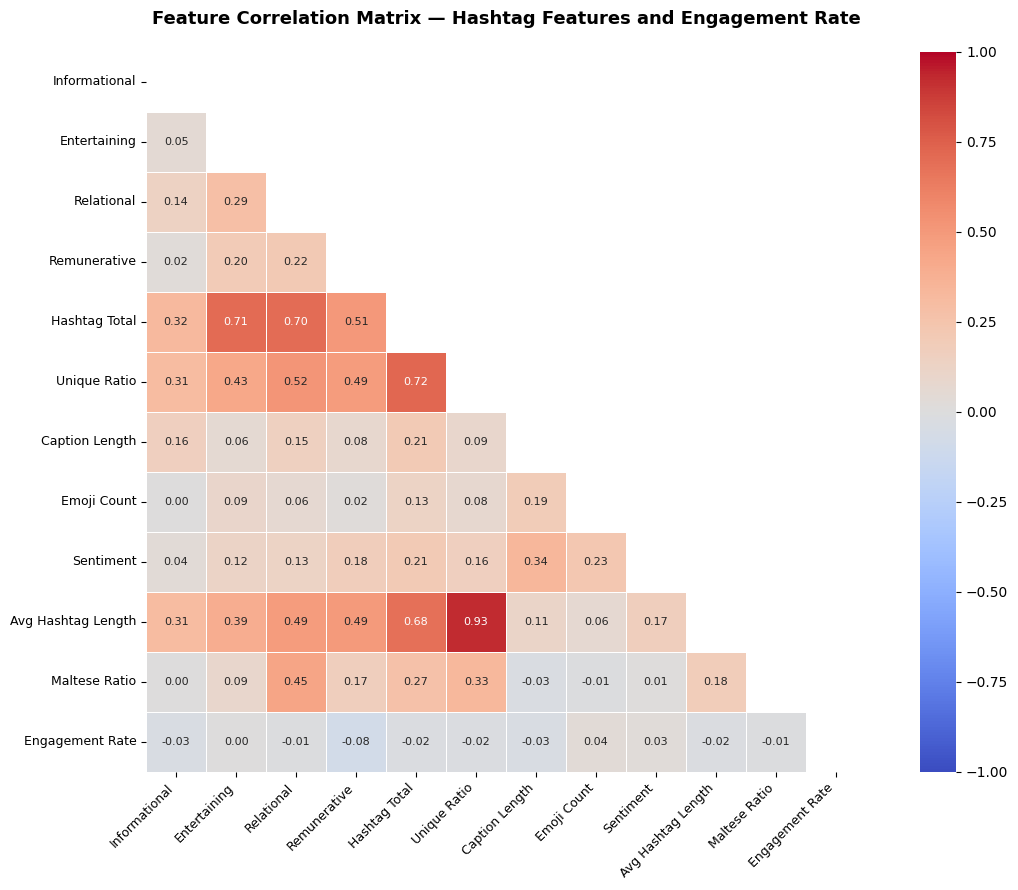

CORRELATIONS WITH ENGAGEMENT RATE
  Remunerative         r=-0.079  weak ↓ negative
  Emoji Count          r= 0.037  weak ↑ positive
  Informational        r=-0.035  weak ↓ negative
  Caption Length       r=-0.032  weak ↓ negative
  Sentiment            r= 0.027  weak ↑ positive
  Hashtag Total        r=-0.022  weak ↓ negative
  Avg Hashtag Length   r=-0.019  weak ↓ negative
  Unique Ratio         r=-0.017  weak ↓ negative
  Relational           r=-0.012  weak ↓ negative
  Maltese Ratio        r=-0.012  weak ↓ negative
  Entertaining         r= 0.004  weak ↑ positive

Correlation heatmap saved to outputs/correlation_heatmap.png


In [12]:
# Correlation Heatmap 
# Shows relationships between all features and engagement rate
# Informs feature selection rationale for ML modelling

corr_features = [
    'informational_count', 'entertaining_count',
    'relational_count', 'remunerative_count',
    'hashtag_total', 'unique_hashtag_ratio',
    'caption_length', 'emoji_count',
    'sentiment_polarity',
    'avg_hashtag_length', 'hashtag_maltese_ratio',
    'engagement_rate'         
]

corr_labels = [
    'Informational', 'Entertaining', 'Relational', 'Remunerative',
    'Hashtag Total', 'Unique Ratio', 'Caption Length',
    'Emoji Count', 'Sentiment',
    'Avg Hashtag Length', 'Maltese Ratio',
    'Engagement Rate'          
]

corr_matrix = df[corr_features].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle masked

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Feature Correlation Matrix — Hashtag Features and Engagement Rate',
             fontsize=13, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key correlations with engagement
print("CORRELATIONS WITH ENGAGEMENT RATE")
eng_corr = corr_matrix['Engagement Rate'].drop('Engagement Rate').sort_values(
    key=abs, ascending=False)
for feature, corr in eng_corr.items():
    direction = "↑ positive" if corr > 0 else "↓ negative"
    strength = "strong" if abs(corr) > 0.3 else "moderate" if abs(corr) > 0.1 else "weak"
    print(f"  {feature:<20} r={corr:>6.3f}  {strength} {direction}")

print("\nCorrelation heatmap saved to outputs/correlation_heatmap.png")

# Section 10: Machine Learning Modelling 

In [13]:
# Build feature matrix
feature_columns = [
    'informational_count', 'entertaining_count',
    'relational_count', 'remunerative_count',
    'hashtag_total', 'unique_hashtag_ratio',
    'caption_length', 'emoji_count', 'sentiment_polarity',
    'avg_hashtag_length', 'hashtag_maltese_ratio'
]

X = df[feature_columns].copy()
y = df['engagement_level'].copy()

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Feature matrix shape: {X.shape}")
print(f"Target classes: {le.classes_}")
print(f"\nClass distribution:")
for label, count in zip(le.classes_,
                        pd.Series(y_encoded).value_counts().sort_index()):
    print(f"  {label}: {count}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nTraining set: {X_train.shape[0]} posts")
print(f"Test set:     {X_test.shape[0]} posts")

# SMOTE not applied — classes are already perfectly balanced (50/50) via the median-split engagement classification. Oversampling a balanced dataset introduces synthetic noise with no benefit.
X_train_smote, y_train_smote = X_train, y_train

print(f"\nClass balance confirmed — SMOTE not required:")
for label, count in zip(le.classes_,
                        pd.Series(y_train_smote).value_counts().sort_index()):
    print(f"  {label}: {count}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Feature matrix shape: (2916, 11)
Target classes: ['High' 'Low']

Class distribution:
  High: 1458
  Low: 1458

Training set: 2332 posts
Test set:     584 posts

Class balance confirmed — SMOTE not required:
  High: 1166
  Low: 1166


##  Section 10.1: Logistic Regression

In [14]:
# Baseline Model: Logistic Regression
# A baseline model is required to contextualise the performance of the more complex ML models (RF and XGBoost). Without a baseline, a 60% accuracy figure has no reference point. 
# Logistic Regression is chosen as the standard baseline for binary classification tasks (Crowe, 2018). No hyperparameter tuning applied intentionally — this is a naive baseline, not a competitor.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression is sensitive to feature scale unlike tree-based models so we scale here only for the baseline — RF and XGBoost do not need this
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_cv_scores = cross_val_score(
    lr_model, X_train_scaled, y_train,
    cv=cv, scoring='f1_weighted'
)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

print("Logistic Regression (Baseline) Cross-Validation (5-fold):")
print(f"  Mean F1: {lr_cv_scores.mean():.3f} (+/- {lr_cv_scores.std():.3f})")
print(f"\nLogistic Regression (Baseline) Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, lr_predictions):.3f}")
print(f"  Precision: {precision_score(y_test, lr_predictions, average='weighted'):.3f}")
print(f"  Recall:    {recall_score(y_test, lr_predictions, average='weighted'):.3f}")
print(f"  F1 Score:  {f1_score(y_test, lr_predictions, average='weighted'):.3f}")
print(f"\n{classification_report(y_test, lr_predictions, target_names=le.classes_)}")

Logistic Regression (Baseline) Cross-Validation (5-fold):
  Mean F1: 0.559 (+/- 0.019)

Logistic Regression (Baseline) Test Set Performance:
  Accuracy:  0.586
  Precision: 0.586
  Recall:    0.586
  F1 Score:  0.585

              precision    recall  f1-score   support

        High       0.58      0.61      0.60       292
         Low       0.59      0.56      0.58       292

    accuracy                           0.59       584
   macro avg       0.59      0.59      0.59       584
weighted avg       0.59      0.59      0.59       584



## Section 10.2: Hyperparameter Tuning

In [15]:

# Random Forest Tuning 
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

print("Random Forest — Best Parameters:")
for k, v in rf_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"  Best CV F1: {rf_grid.best_score_:.3f}")

rf_model = rf_grid.best_estimator_

# XGBoost Tuning 
xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    xgb_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train, y_train)

print("\nXGBoost — Best Parameters:")
for k, v in xgb_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"  Best CV F1: {xgb_grid.best_score_:.3f}")

xgb_model = xgb_grid.best_estimator_

Random Forest — Best Parameters:
  max_depth: 20
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200
  Best CV F1: 0.636

XGBoost — Best Parameters:
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 200
  subsample: 1.0
  Best CV F1: 0.622


## Section 10.3: Random Forest 

In [16]:
# Train Random Forest 
# Random Forest justified by Gorrepati (2024) for Instagram engagement prediction
# class_weight not set — classes already balanced via median split (50/50)
# rf_model is the tuned best estimator from GridSearchCV above

rf_cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=cv, scoring='f1_weighted')

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print(f"Random Forest Cross-Validation (5-fold):")
print(f"  Mean F1: {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std():.3f})")
print(f"\nRandom Forest Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, rf_predictions):.3f}")
print(f"  Precision: {precision_score(y_test, rf_predictions, average='weighted'):.3f}")
print(f"  Recall:    {recall_score(y_test, rf_predictions, average='weighted'):.3f}")
print(f"  F1 Score:  {f1_score(y_test, rf_predictions, average='weighted'):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_predictions, target_names=le.classes_))

Random Forest Cross-Validation (5-fold):
  Mean F1: 0.636 (+/- 0.006)

Random Forest Test Set Performance:
  Accuracy:  0.630
  Precision: 0.630
  Recall:    0.630
  F1 Score:  0.630

Classification Report:
              precision    recall  f1-score   support

        High       0.63      0.64      0.63       292
         Low       0.63      0.62      0.63       292

    accuracy                           0.63       584
   macro avg       0.63      0.63      0.63       584
weighted avg       0.63      0.63      0.63       584



## Section 10.4: XGBoost

In [17]:
# Train XGBoost 
# xgb_model is the tuned best estimator from GridSearchCV above

xgb_cv_scores = cross_val_score(
    xgb_model, X_train, y_train,
    cv=cv, scoring='f1_weighted')

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

print(f"XGBoost Cross-Validation (5-fold):")
print(f"  Mean F1: {xgb_cv_scores.mean():.3f} (+/- {xgb_cv_scores.std():.3f})")
print(f"\nXGBoost Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_predictions):.3f}")
print(f"  Precision: {precision_score(y_test, xgb_predictions, average='weighted'):.3f}")
print(f"  Recall:    {recall_score(y_test, xgb_predictions, average='weighted'):.3f}")
print(f"  F1 Score:  {f1_score(y_test, xgb_predictions, average='weighted'):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_predictions, target_names=le.classes_))

XGBoost Cross-Validation (5-fold):
  Mean F1: 0.622 (+/- 0.022)

XGBoost Test Set Performance:
  Accuracy:  0.627
  Precision: 0.627
  Recall:    0.627
  F1 Score:  0.627

Classification Report:
              precision    recall  f1-score   support

        High       0.62      0.65      0.63       292
         Low       0.63      0.61      0.62       292

    accuracy                           0.63       584
   macro avg       0.63      0.63      0.63       584
weighted avg       0.63      0.63      0.63       584



## Section 10.5: Model Comparision Summary

In [18]:
# Model Comparison Summary

print("MODEL COMPARISON SUMMARY")
print(f"{'Model':<32} {'CV F1':>8} {'Test F1':>8}")
print(f"{'Logistic Regression (Baseline)':<32} {lr_cv_scores.mean():>8.3f} {f1_score(y_test, lr_predictions, average='weighted'):>8.3f}")
print(f"{'Random Forest':<32} {rf_cv_scores.mean():>8.3f} {f1_score(y_test, rf_predictions, average='weighted'):>8.3f}")
print(f"{'XGBoost':<32} {xgb_cv_scores.mean():>8.3f} {f1_score(y_test, xgb_predictions, average='weighted'):>8.3f}")

MODEL COMPARISON SUMMARY
Model                               CV F1  Test F1
Logistic Regression (Baseline)      0.559    0.585
Random Forest                       0.636    0.630
XGBoost                             0.622    0.627


# Section 11: Model Evaluation

## Section 11.1: Confusion Matrices

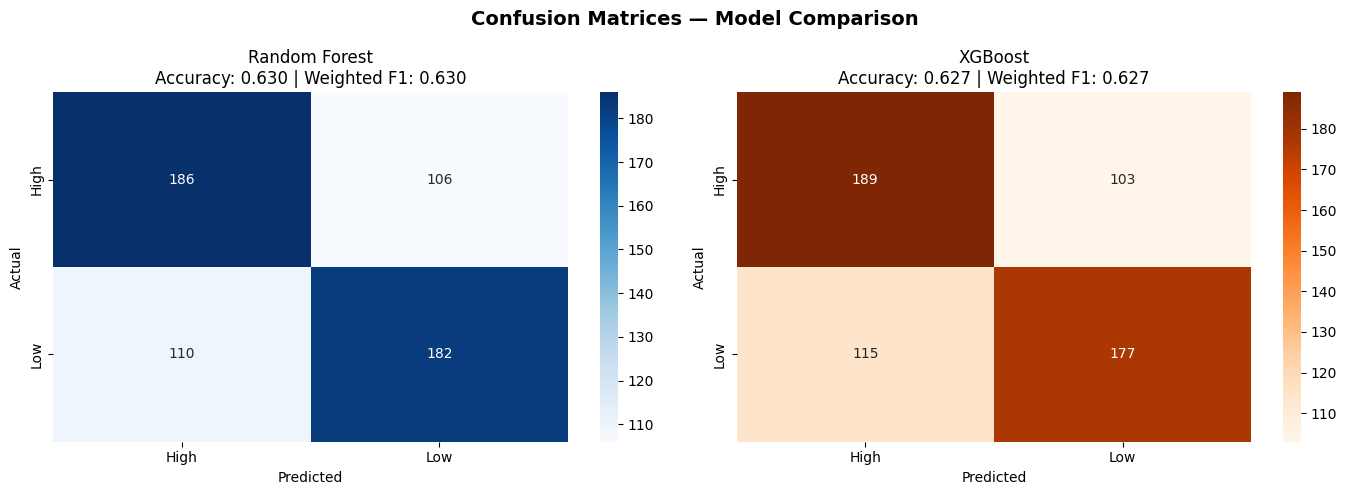

Confusion matrices saved to outputs/confusion_matrices.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Model Comparison',
             fontsize=14, fontweight='bold')

rf_cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Random Forest\nAccuracy: {accuracy_score(y_test, rf_predictions):.3f} | Weighted F1: {f1_score(y_test, rf_predictions, average="weighted"):.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

xgb_cm = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f'XGBoost\nAccuracy: {accuracy_score(y_test, xgb_predictions):.3f} | Weighted F1: {f1_score(y_test, xgb_predictions, average="weighted"):.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved to outputs/confusion_matrices.png")

## Section 11.2: Feature Importance 

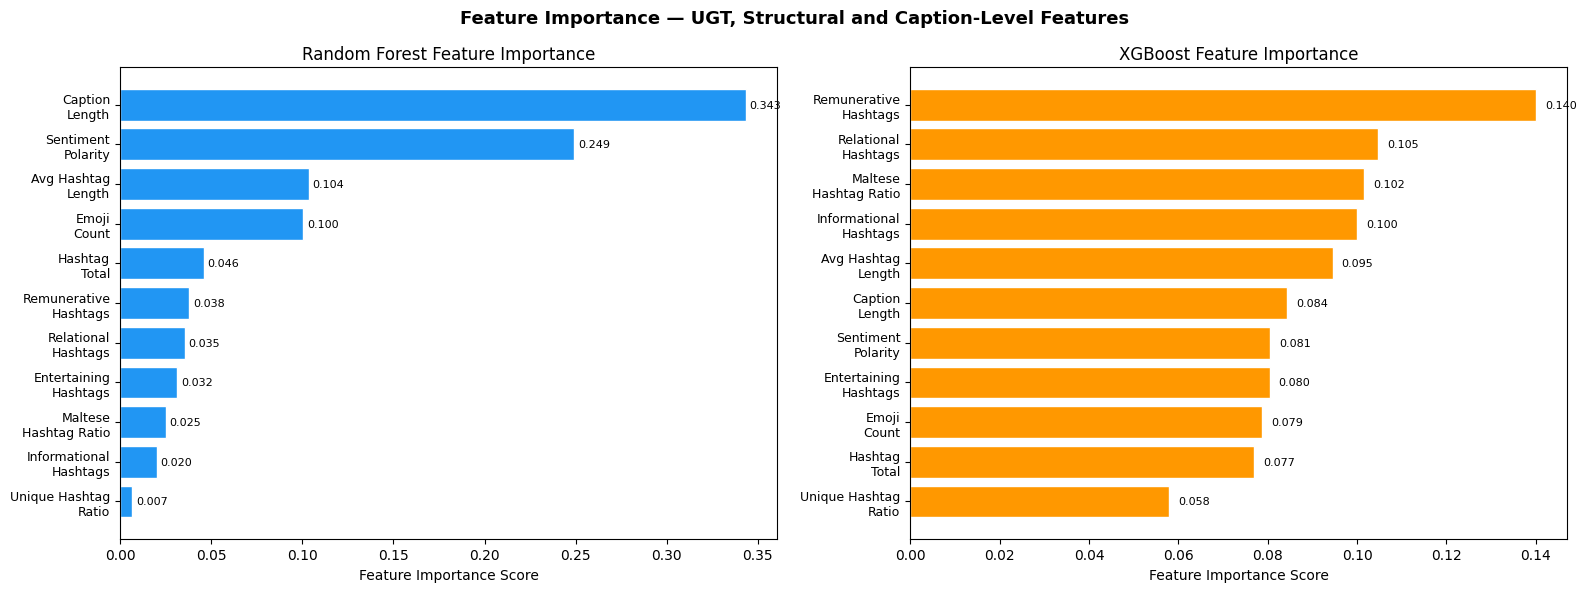


Random Forest — Feature Ranking:
  1. Caption Length: 0.343
  2. Sentiment Polarity: 0.249
  3. Avg Hashtag Length: 0.104
  4. Emoji Count: 0.100
  5. Hashtag Total: 0.046
  6. Remunerative Hashtags: 0.038
  7. Relational Hashtags: 0.035
  8. Entertaining Hashtags: 0.032
  9. Maltese Hashtag Ratio: 0.025
  10. Informational Hashtags: 0.020
  11. Unique Hashtag Ratio: 0.007

XGBoost — Feature Ranking:
  1. Remunerative Hashtags: 0.140
  2. Relational Hashtags: 0.105
  3. Maltese Hashtag Ratio: 0.102
  4. Informational Hashtags: 0.100
  5. Avg Hashtag Length: 0.095
  6. Caption Length: 0.084
  7. Sentiment Polarity: 0.081
  8. Entertaining Hashtags: 0.080
  9. Emoji Count: 0.079
  10. Hashtag Total: 0.077
  11. Unique Hashtag Ratio: 0.058


In [29]:

feature_names = [
    'Informational\nHashtags', 'Entertaining\nHashtags',
    'Relational\nHashtags', 'Remunerative\nHashtags',
    'Hashtag\nTotal', 'Unique Hashtag\nRatio',
    'Caption\nLength', 'Emoji\nCount', 'Sentiment\nPolarity', 'Avg Hashtag\nLength', 'Maltese\nHashtag Ratio'
]

rf_importance = rf_model.feature_importances_
xgb_importance = xgb_model.feature_importances_
rf_sorted_idx = rf_importance.argsort()[::-1]
xgb_sorted_idx = xgb_importance.argsort()[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — UGT, Structural and Caption-Level Features',
             fontsize=13, fontweight='bold')

rf_sorted = rf_importance[rf_sorted_idx]
names_rf = [feature_names[i] for i in rf_sorted_idx]
bars = axes[0].barh(range(len(names_rf)), rf_sorted,
                    color='#2196F3', edgecolor='white')
axes[0].set_yticks(range(len(names_rf)))
axes[0].set_yticklabels(names_rf, fontsize=9)
axes[0].set_xlabel('Feature Importance Score')
axes[0].set_title('Random Forest Feature Importance')
axes[0].invert_yaxis()
for bar, val in zip(bars, rf_sorted):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

xgb_sorted = xgb_importance[xgb_sorted_idx]
names_xgb = [feature_names[i] for i in xgb_sorted_idx]
bars2 = axes[1].barh(range(len(names_xgb)), xgb_sorted,
                     color='#FF9800', edgecolor='white')
axes[1].set_yticks(range(len(names_xgb)))
axes[1].set_yticklabels(names_xgb, fontsize=9)
axes[1].set_xlabel('Feature Importance Score')
axes[1].set_title('XGBoost Feature Importance')
axes[1].invert_yaxis()
for bar, val in zip(bars2, xgb_sorted):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRandom Forest — Feature Ranking:")
for i, idx in enumerate(rf_sorted_idx, 1):
    print(f"  {i}. {feature_names[idx].replace(chr(10), ' ')}: {rf_importance[idx]:.3f}")

print("\nXGBoost — Feature Ranking:")
for i, idx in enumerate(xgb_sorted_idx, 1):
    print(f"  {i}. {feature_names[idx].replace(chr(10), ' ')}: {xgb_importance[idx]:.3f}")

# Section 12: Hypothesis Testing 

##  Section 12.1: Hashtag Combination Analysis

Engagement by Hashtag Combination:
                           mean_engagement  post_count  high_engagement_pct
hashtag_combination                                                        
Entertaining Only                    0.460         234               53.419
No Hashtags                          0.369        1655               50.030
Relational + Entertaining            0.335         371               50.943
Relational Only                      0.311         418               53.828
Informational Only                   0.144         127               40.157
Remunerative Only                    0.124         111               36.036


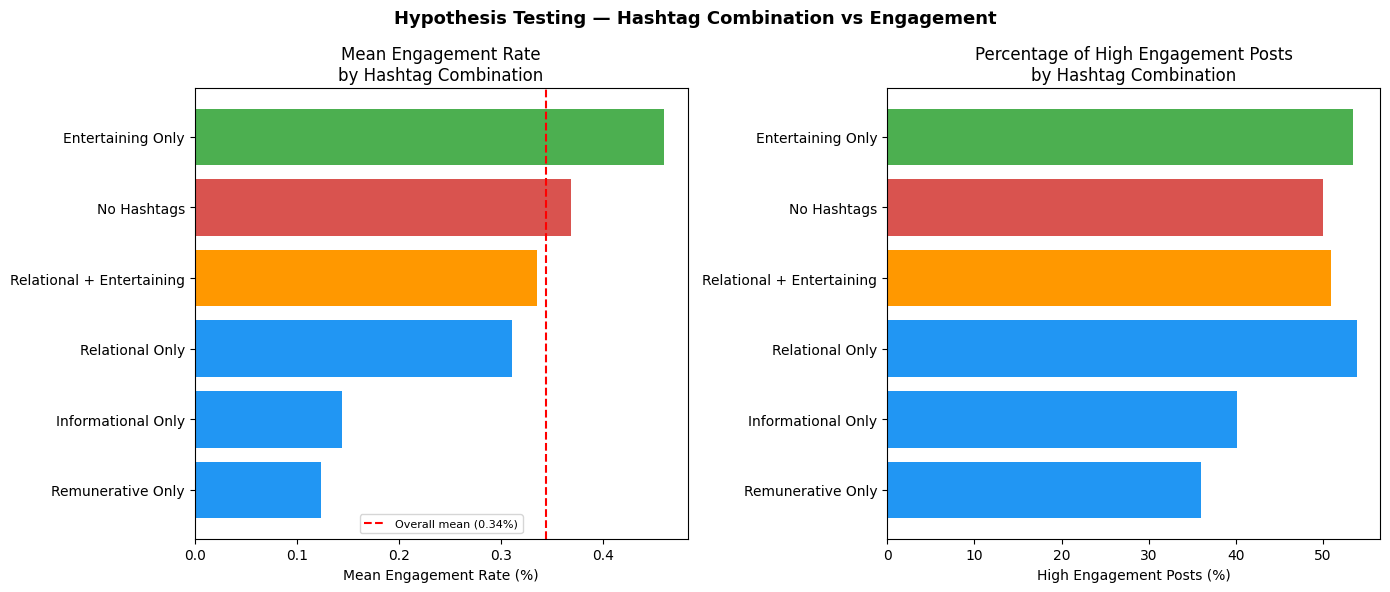

Hypothesis test saved to outputs/hypothesis_test.png


In [21]:

def categorise_combination(row):
    has_relational = row['relational_count'] > 0
    has_entertaining = row['entertaining_count'] > 0
    has_informational = row['informational_count'] > 0
    has_remunerative = row['remunerative_count'] > 0

    if has_relational and has_entertaining:
        return 'Relational + Entertaining'
    elif has_relational and not has_entertaining:
        return 'Relational Only'
    elif has_entertaining and not has_relational:
        return 'Entertaining Only'
    elif has_informational:
        return 'Informational Only'
    elif has_remunerative:
        return 'Remunerative Only'
    else:
        return 'No Hashtags'

df['hashtag_combination'] = df.apply(categorise_combination, axis=1)

combination_engagement = df.groupby('hashtag_combination').agg(
    mean_engagement=('engagement_rate', 'mean'),
    post_count=('engagement_rate', 'count'),
    high_engagement_pct=('engagement_level',
                         lambda x: (x == 'High').sum() / len(x) * 100)
).round(3)

print("Engagement by Hashtag Combination:")
print(combination_engagement.sort_values('mean_engagement', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hypothesis Testing — Hashtag Combination vs Engagement',
             fontsize=13, fontweight='bold')

combo_sorted = combination_engagement.sort_values('mean_engagement', ascending=True)
colors = ['#d9534f' if idx == 'No Hashtags'
          else '#4CAF50' if idx == 'Entertaining Only'
          else '#FF9800' if idx == 'Relational + Entertaining'
          else '#2196F3' for idx in combo_sorted.index]

axes[0].barh(combo_sorted.index, combo_sorted['mean_engagement'], color=colors)
axes[0].set_xlabel('Mean Engagement Rate (%)')
axes[0].set_title('Mean Engagement Rate\nby Hashtag Combination')
axes[0].axvline(x=df['engagement_rate'].mean(), color='red',
                linestyle='--',
                label=f'Overall mean ({df["engagement_rate"].mean():.2f}%)')
axes[0].legend(fontsize=8)

axes[1].barh(combo_sorted.index,
             combo_sorted.loc[combo_sorted.index, 'high_engagement_pct'],
             color=colors)
axes[1].set_xlabel('High Engagement Posts (%)')
axes[1].set_title('Percentage of High Engagement Posts\nby Hashtag Combination')

plt.tight_layout()
plt.savefig('outputs/hypothesis_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hypothesis test saved to outputs/hypothesis_test.png")

## Section 12.2: Statistical Significance Testing

In [22]:
# Kruskal-Wallis overall test 
groups = [
    df[df['hashtag_combination'] == combo]['engagement_rate'].values
    for combo in df['hashtag_combination'].unique()
]

h_stat, p_value = stats.kruskal(*groups)

# Store hypothesis test values before Section 13 overwrites h_stat and p_value
hypothesis_h_stat = h_stat
hypothesis_p_value = p_value

print("KRUSKAL-WALLIS TEST — Overall")
print(f"  H-statistic: {h_stat:.3f}")
print(f"  p-value:     {p_value:.4f}")
if p_value < 0.05:
    print(f"  Result:      SIGNIFICANT — engagement differs across combinations")
else:
    print(f"  Result:      NOT SIGNIFICANT")

# Pairwise post-hoc tests with Bonferroni correction 
combos = df['hashtag_combination'].unique()
n_comparisons = len(list(combinations(combos, 2)))
bonferroni_alpha = 0.05 / n_comparisons

print(f"PAIRWISE TESTS — Bonferroni corrected (alpha = {bonferroni_alpha:.4f})")
print(f"{'Comparison':<45} {'p-value':>10} {'Significant':>12}")

significant_pairs = []

for combo1, combo2 in combinations(combos, 2):
    group1 = df[df['hashtag_combination'] == combo1]['engagement_rate'].values
    group2 = df[df['hashtag_combination'] == combo2]['engagement_rate'].values
    _, p = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    sig = "Yes ✓" if p < bonferroni_alpha else "No"
    comparison = f"{combo1} vs {combo2}"
    print(f"  {comparison:<43} {p:>10.4f} {sig:>12}")
    if p < bonferroni_alpha:
        significant_pairs.append((combo1, combo2, p))

print(f"\nTotal comparisons: {n_comparisons}")
print(f"Significant pairs: {len(significant_pairs)}")

# Hypothesis specific test 
print("HYPOTHESIS TEST — Relational + Entertaining vs others")

rel_ent       = df[df['hashtag_combination'] == 'Relational + Entertaining']['engagement_rate'].values
entertaining  = df[df['hashtag_combination'] == 'Entertaining Only']['engagement_rate'].values
informational = df[df['hashtag_combination'] == 'Informational Only']['engagement_rate'].values
remunerative  = df[df['hashtag_combination'] == 'Remunerative Only']['engagement_rate'].values

_, p_vs_ent  = stats.mannwhitneyu(rel_ent, entertaining,  alternative='greater')
_, p_vs_info = stats.mannwhitneyu(rel_ent, informational, alternative='greater')
_, p_vs_rem  = stats.mannwhitneyu(rel_ent, remunerative,  alternative='greater')

print(f"  Relational+Entertaining vs Entertaining Only:  p={p_vs_ent:.4f}  {'✓ Supported' if p_vs_ent  < 0.05 else '✗ Not supported'}")
print(f"  Relational+Entertaining vs Informational Only: p={p_vs_info:.4f}  {'✓ Supported' if p_vs_info < 0.05 else '✗ Not supported'}")
print(f"  Relational+Entertaining vs Remunerative Only:  p={p_vs_rem:.4f}  {'✓ Supported' if p_vs_rem  < 0.05 else '✗ Not supported'}")

print("HYPOTHESIS CONCLUSION")

if p_vs_ent < 0.05 and p_vs_info < 0.05 and p_vs_rem < 0.05:
    print("  SUPPORTED")
    print("  Relational + Entertaining significantly outperforms all")
    print("  other combinations.")
elif p_vs_info < 0.05 and p_vs_rem < 0.05 and p_vs_ent >= 0.05:
    print("  NOT SUPPORTED")
    print("  Relational + Entertaining does not outperform Entertaining Only")
    print(f"  (p={p_vs_ent:.4f}), which achieved the highest mean engagement.")
    print("  It does outperform Informational and Remunerative combinations,")
    print("  but this does not constitute support for the hypothesis as stated.")
    print("  Finding: single-category Entertaining content outperforms mixed")
    print("  combinations in this dataset, contrary to the prediction.")
else:
    print("  NOT SUPPORTED — differences not statistically significant")

KRUSKAL-WALLIS TEST — Overall
  H-statistic: 38.945
  p-value:     0.0000
  Result:      SIGNIFICANT — engagement differs across combinations
PAIRWISE TESTS — Bonferroni corrected (alpha = 0.0033)
Comparison                                       p-value  Significant
  Relational + Entertaining vs Informational Only     0.0001        Yes ✓
  Relational + Entertaining vs Entertaining Only     0.8328           No
  Relational + Entertaining vs No Hashtags        0.0178           No
  Relational + Entertaining vs Remunerative Only     0.0000        Yes ✓
  Relational + Entertaining vs Relational Only     0.7180           No
  Informational Only vs Entertaining Only         0.0002        Yes ✓
  Informational Only vs No Hashtags               0.0074           No
  Informational Only vs Remunerative Only         0.3473           No
  Informational Only vs Relational Only           0.0002        Yes ✓
  Entertaining Only vs No Hashtags                0.0760           No
  Entertaining Only vs

# Section 13: Hashtag Count Optimisation Analysis.

HASHTAG COUNT OPTIMISATION ANALYSIS

Bracket                 Posts   Mean Eng   Median Eng   High %
  0 (No Hashtags)        1614      0.361%        0.107%     50.0%
  1-3                     532      0.348%        0.115%     51.3%
  4-6                     623      0.324%        0.104%     49.3%
  7-10                    100      0.256%        0.095%     46.0%
  11-15                    31      0.218%        0.100%     45.2%
  16+                      16      0.180%        0.142%     68.8%

Kruskal-Wallis: H=2.384, p=0.7939
Result: NOT SIGNIFICANT


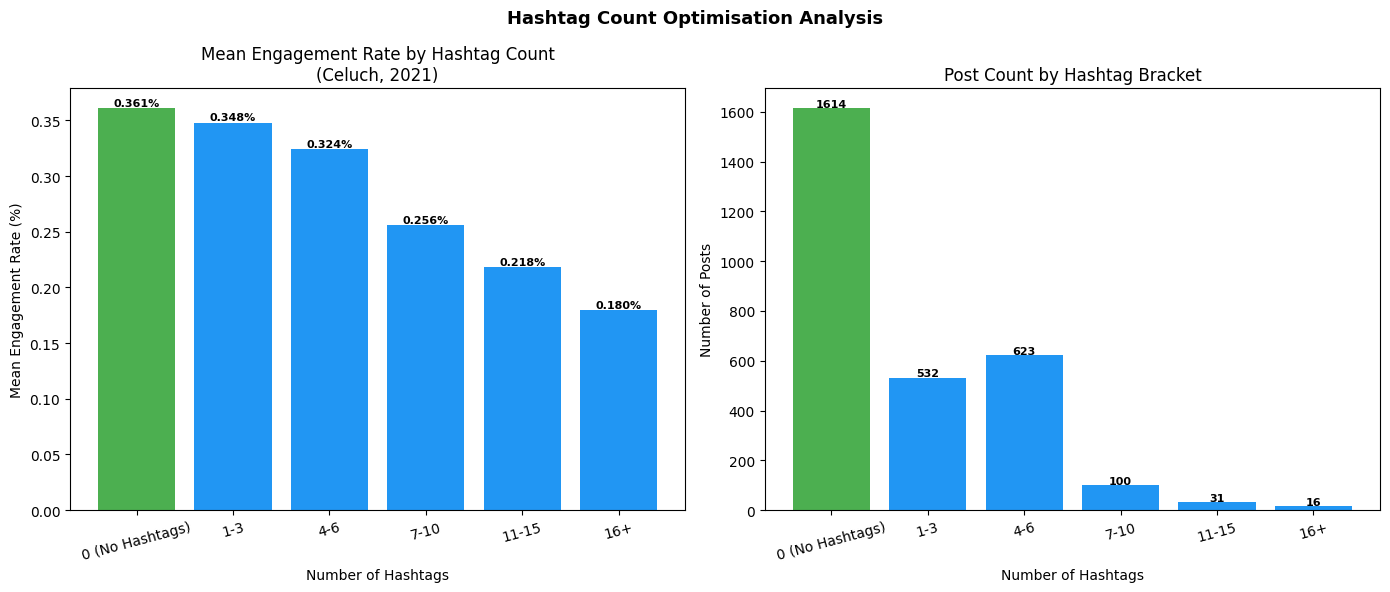

Hashtag count analysis saved to outputs/hashtag_count_optimisation.png


In [23]:


# Create hashtag count brackets 
def hashtag_bracket(count):
    if count == 0:
        return '0 (No Hashtags)'
    elif count <= 3:
        return '1-3'
    elif count <= 6:
        return '4-6'
    elif count <= 10:
        return '7-10'
    elif count <= 15:
        return '11-15'
    else:
        return '16+'

bracket_order = ['0 (No Hashtags)', '1-3', '4-6', '7-10', '11-15', '16+']

df['hashtag_bracket'] = df['hashtag_total'].apply(hashtag_bracket)

bracket_stats = df.groupby('hashtag_bracket').agg(
    post_count=('engagement_rate', 'count'),
    mean_engagement=('engagement_rate', 'mean'),
    median_engagement=('engagement_rate', 'median'),
    high_pct=('engagement_level', lambda x: (x == 'High').sum() / len(x) * 100)
).round(3)

bracket_stats = bracket_stats.reindex(bracket_order)

print("HASHTAG COUNT OPTIMISATION ANALYSIS")
print(f"\n{'Bracket':<20} {'Posts':>8} {'Mean Eng':>10} {'Median Eng':>12} {'High %':>8}")
for bracket, row in bracket_stats.iterrows():
    print(f"  {bracket:<18} {int(row['post_count']):>8} {row['mean_engagement']:>10.3f}% {row['median_engagement']:>12.3f}% {row['high_pct']:>8.1f}%")

# Kruskal-Wallis test across brackets 
bracket_groups = [
    df[df['hashtag_bracket'] == b]['engagement_rate'].values
    for b in bracket_order
    if len(df[df['hashtag_bracket'] == b]) > 0
]

h_stat, p_value = scipy_stats.kruskal(*bracket_groups)
print(f"\nKruskal-Wallis: H={h_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("Result: SIGNIFICANT — hashtag count affects engagement")
else:
    print("Result: NOT SIGNIFICANT")

# Visualisation 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hashtag Count Optimisation Analysis', fontsize=13, fontweight='bold')

best_bracket = bracket_stats['mean_engagement'].idxmax()
colors = ['#4CAF50' if b == best_bracket else '#2196F3' for b in bracket_order]

axes[0].bar(bracket_stats.index, bracket_stats['mean_engagement'], color=colors)
axes[0].set_xlabel('Number of Hashtags')
axes[0].set_ylabel('Mean Engagement Rate (%)')
axes[0].set_title('Mean Engagement Rate by Hashtag Count\n(Celuch, 2021)')
axes[0].tick_params(axis='x', rotation=15)
for i, (bracket, row) in enumerate(bracket_stats.iterrows()):
    axes[0].text(i, row['mean_engagement'] + 0.002,
                f"{row['mean_engagement']:.3f}%",
                ha='center', fontsize=8, fontweight='bold')

axes[1].bar(bracket_stats.index, bracket_stats['post_count'], color=colors)
axes[1].set_xlabel('Number of Hashtags')
axes[1].set_ylabel('Number of Posts')
axes[1].set_title('Post Count by Hashtag Bracket')
axes[1].tick_params(axis='x', rotation=15)
for i, (bracket, row) in enumerate(bracket_stats.iterrows()):
    axes[1].text(i, row['post_count'] + 5,
                str(int(row['post_count'])),
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/hashtag_count_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hashtag count analysis saved to outputs/hashtag_count_optimisation.png")

# Section 14: Account Category Analysis.

CATEGORY ANALYSIS SUMMARY

Creators & Influencers:
  Posts: 489 | Mean engagement: 0.703% | High %: 78.1%
  Dominant hashtag type: Informational(0.07) Entertaining(0.60) Relational(0.23) Remunerative(0.11)

Local Businesses:
  Posts: 477 | Mean engagement: 0.280% | High %: 28.3%
  Dominant hashtag type: Informational(0.04) Entertaining(0.51) Relational(0.62) Remunerative(0.90)

Media & News:
  Posts: 499 | Mean engagement: 0.185% | High %: 30.1%
  Dominant hashtag type: Informational(0.26) Entertaining(0.04) Relational(0.04) Remunerative(0.06)

Tourism & Hospitality:
  Posts: 477 | Mean engagement: 0.129% | High %: 41.9%
  Dominant hashtag type: Informational(0.09) Entertaining(0.60) Relational(1.07) Remunerative(0.81)

Government & Public:
  Posts: 500 | Mean engagement: 0.173% | High %: 40.8%
  Dominant hashtag type: Informational(0.37) Entertaining(0.19) Relational(0.71) Remunerative(0.11)

Sports & Fitness:
  Posts: 474 | Mean engagement: 0.603% | High %: 81.6%
  Dominant hashtag t

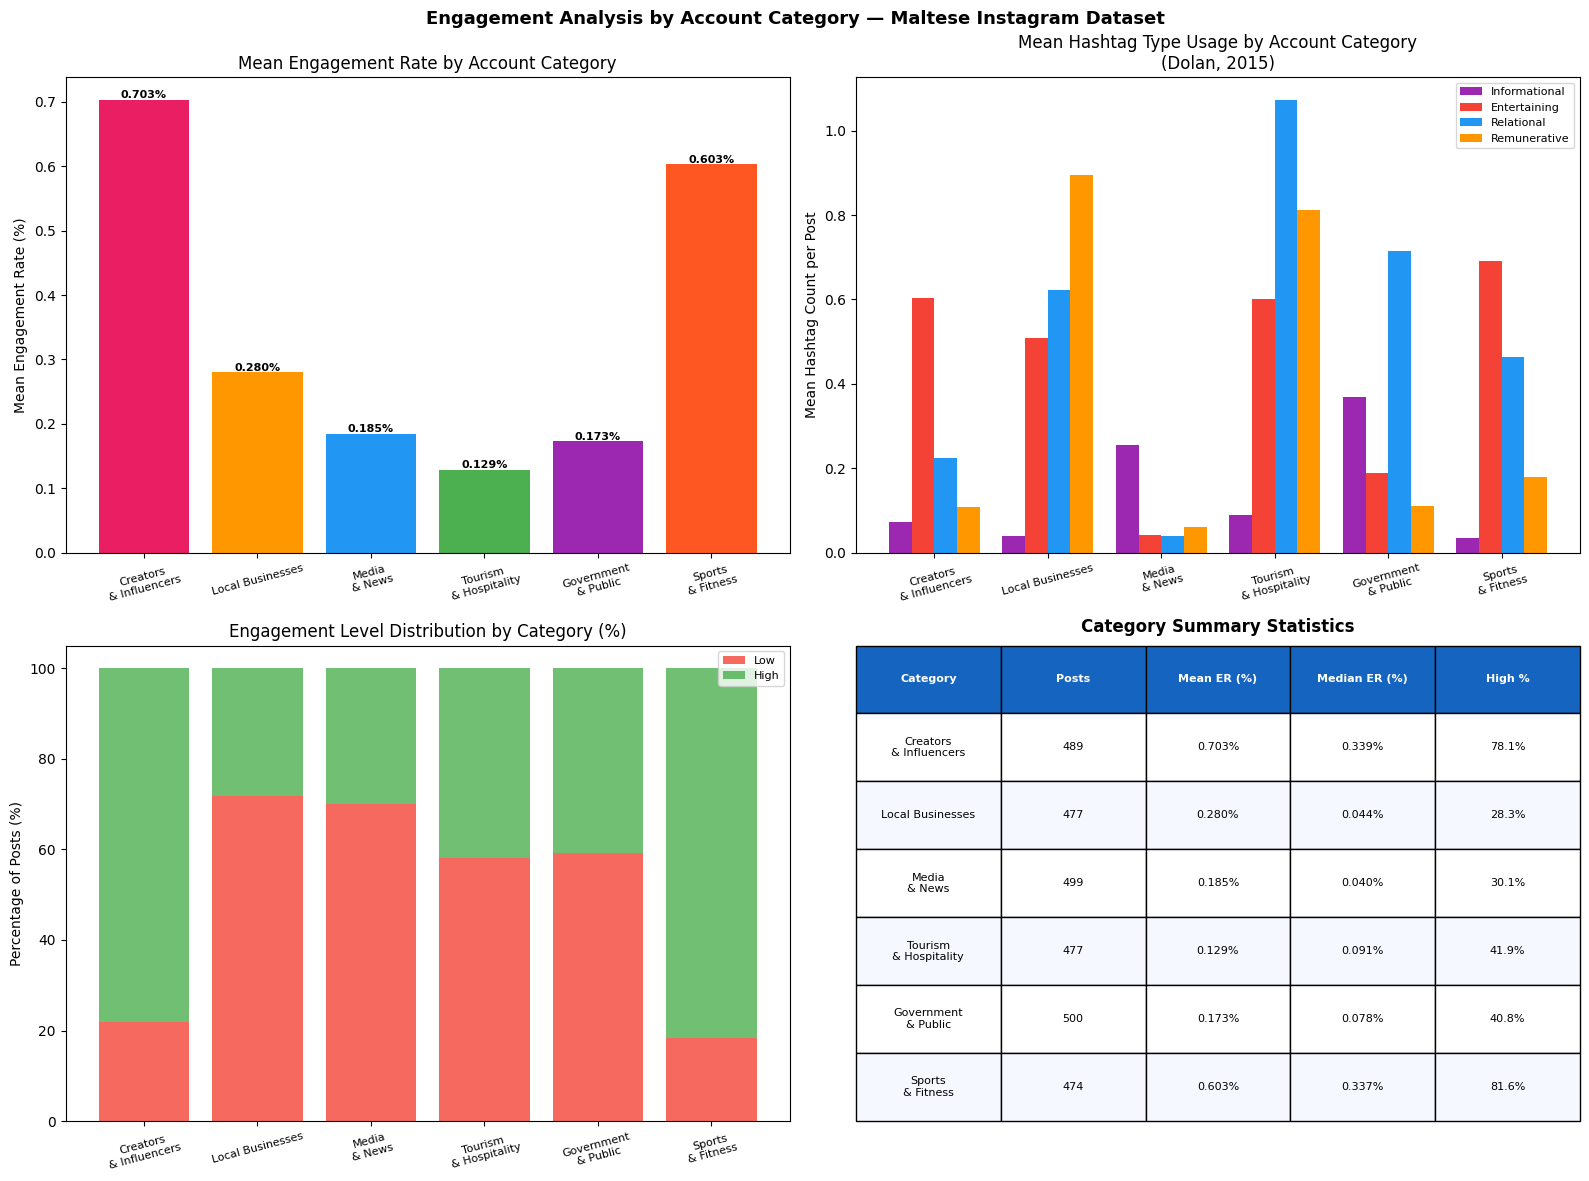

Category analysis saved to outputs/category_analysis.png


In [30]:

category_order = [
    'Creators & Influencers', 'Local Businesses', 'Media & News',
    'Tourism & Hospitality', 'Government & Public', 'Sports & Fitness'
]

# Category summary statistics 
cat_stats = df.groupby('account_category').agg(
    posts=('engagement_rate', 'count'),
    mean_engagement=('engagement_rate', 'mean'),
    median_engagement=('engagement_rate', 'median'),
    high_pct=('engagement_level', lambda x: (x == 'High').sum() / len(x) * 100),
    mean_informational=('informational_count', 'mean'),
    mean_entertaining=('entertaining_count', 'mean'),
    mean_relational=('relational_count', 'mean'),
    mean_remunerative=('remunerative_count', 'mean'),
).round(3)

print("CATEGORY ANALYSIS SUMMARY")
for cat in category_order:
    if cat in cat_stats.index:
        row = cat_stats.loc[cat]
        print(f"\n{cat}:")
        print(f"  Posts: {int(row['posts'])} | Mean engagement: {row['mean_engagement']:.3f}% | High %: {row['high_pct']:.1f}%")
        print(f"  Dominant hashtag type: Informational({row['mean_informational']:.2f}) Entertaining({row['mean_entertaining']:.2f}) Relational({row['mean_relational']:.2f}) Remunerative({row['mean_remunerative']:.2f})")

# Visualisation 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Engagement Analysis by Account Category — Maltese Instagram Dataset',
             fontsize=13, fontweight='bold')

cat_stats_ordered = cat_stats.reindex(category_order)

# Plot 1: Mean engagement by category
ax = axes[0, 0]
colors = ['#E91E63', '#FF9800', '#2196F3', '#4CAF50', '#9C27B0', '#FF5722']
bars = ax.bar(range(len(category_order)),
              cat_stats_ordered['mean_engagement'], color=colors)
ax.set_xticks(range(len(category_order)))
ax.set_xticklabels([c.replace(' & ', '\n& ') for c in category_order],
                   fontsize=8, rotation=15)
ax.set_ylabel('Mean Engagement Rate (%)')
ax.set_title('Mean Engagement Rate by Account Category')
for bar, val in zip(bars, cat_stats_ordered['mean_engagement']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}%', ha='center', fontsize=8, fontweight='bold')

# Plot 2: Mean hashtag type by category
ax = axes[0, 1]
x = np.arange(len(category_order))
width = 0.2
ax.bar(x - 1.5*width, cat_stats_ordered['mean_informational'],
       width, label='Informational', color='#9C27B0')
ax.bar(x - 0.5*width, cat_stats_ordered['mean_entertaining'],
       width, label='Entertaining', color='#F44336')
ax.bar(x + 0.5*width, cat_stats_ordered['mean_relational'],
       width, label='Relational', color='#2196F3')
ax.bar(x + 1.5*width, cat_stats_ordered['mean_remunerative'],
       width, label='Remunerative', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels([c.replace(' & ', '\n& ') for c in category_order],
                   fontsize=8, rotation=15)
ax.set_ylabel('Mean Hashtag Count per Post')
ax.set_title('Mean Hashtag Type Usage by Account Category\n(Dolan, 2015)')
ax.legend(fontsize=8)

# Plot 3: Engagement level distribution by category
ax = axes[1, 0]
high_pcts = cat_stats_ordered['high_pct']
low_pcts = 100 - high_pcts
bottom = np.zeros(len(category_order))
ax.bar(range(len(category_order)), low_pcts,
       label='Low', color='#F44336', alpha=0.8)
ax.bar(range(len(category_order)), high_pcts,
       bottom=low_pcts, label='High', color='#4CAF50', alpha=0.8)
ax.set_xticks(range(len(category_order)))
ax.set_xticklabels([c.replace(' & ', '\n& ') for c in category_order],
                   fontsize=8, rotation=15)
ax.set_ylabel('Percentage of Posts (%)')
ax.set_title('Engagement Level Distribution by Category (%)')
ax.legend(fontsize=8)

# Plot 4: Summary table
ax = axes[1, 1]
ax.axis('off')
table_data = []
for cat in category_order:
    if cat in cat_stats.index:
        row = cat_stats.loc[cat]
        table_data.append([
            cat.replace(' & ', '\n& '),
            str(int(row['posts'])),
            f"{row['mean_engagement']:.3f}%",
            f"{row['median_engagement']:.3f}%",
            f"{row['high_pct']:.1f}%"
        ])

table = ax.table(
    cellText=table_data,
    colLabels=['Category', 'Posts', 'Mean ER (%)', 'Median ER (%)', 'High %'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F5F9FF')

ax.set_title('Category Summary Statistics', fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('outputs/category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Category analysis saved to outputs/category_analysis.png")

# Section 15: Per-Category Hypothesis Testing.

PER-CATEGORY KRUSKAL-WALLIS ANALYSIS


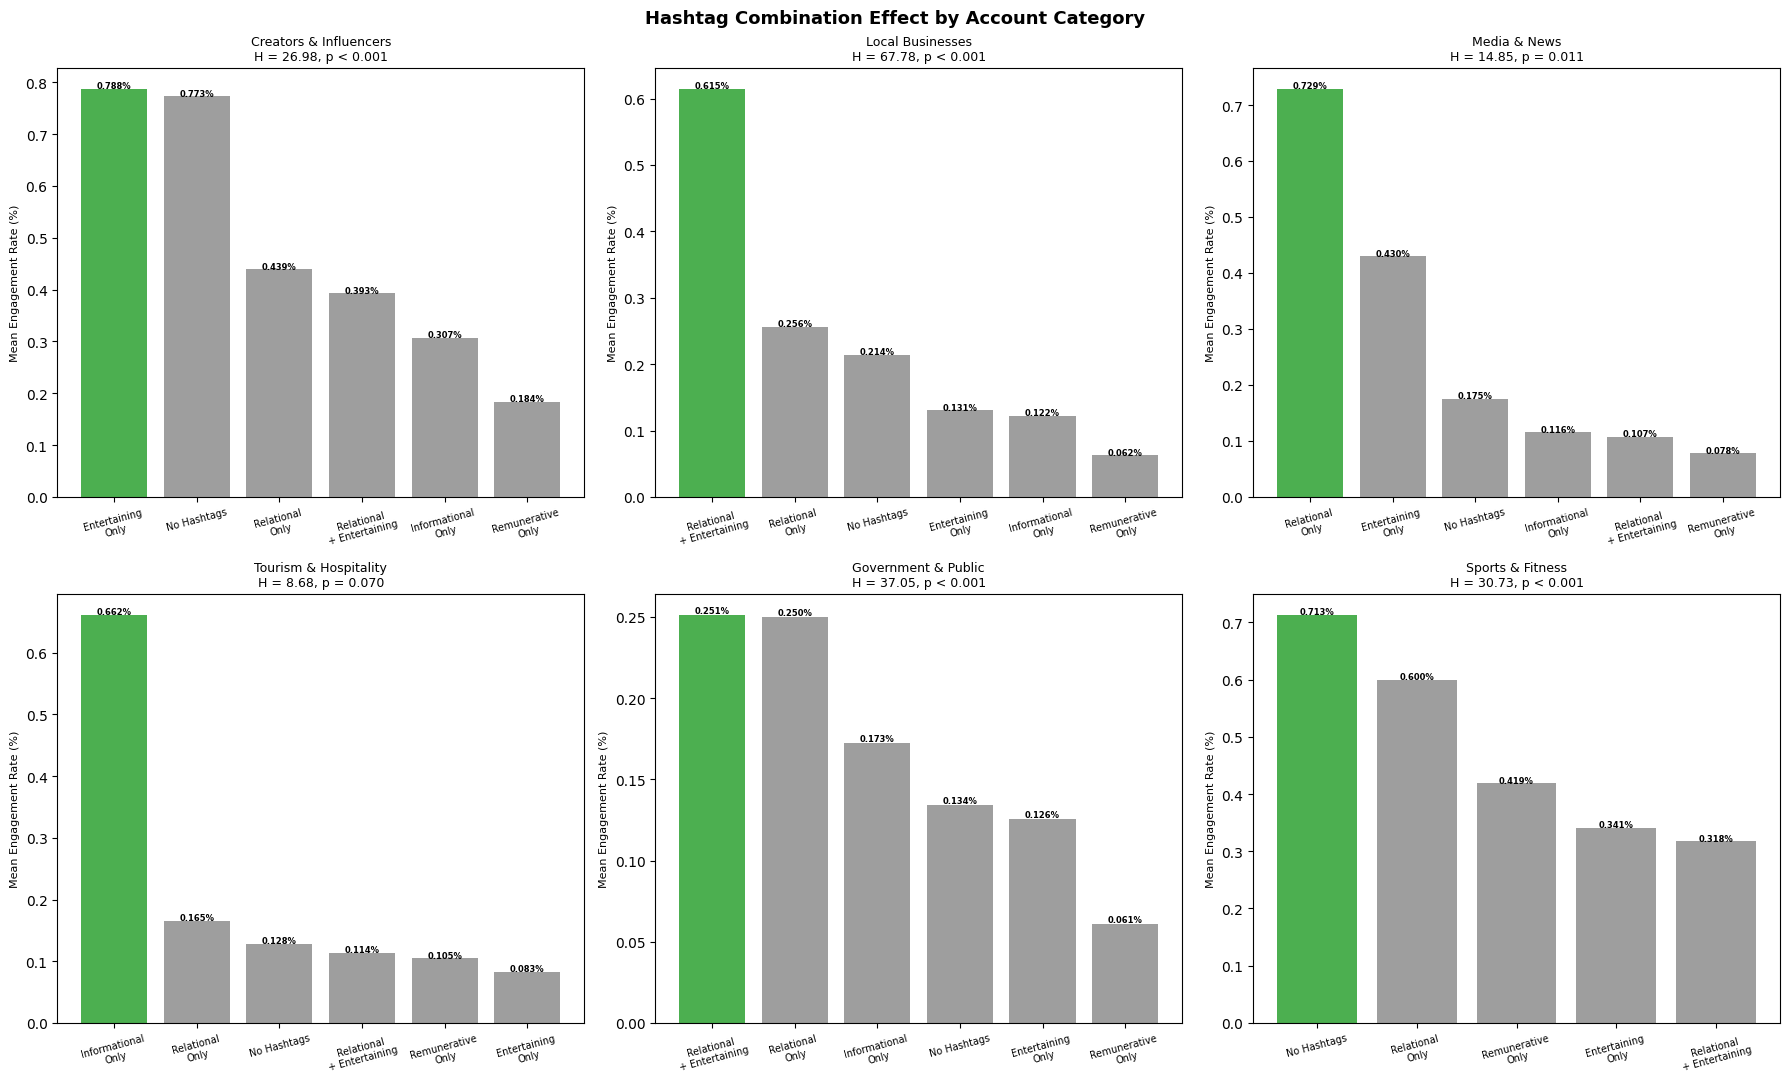


Significant hashtag combination effect:
  ✓ Creators & Influencers
  ✓ Local Businesses
  ✓ Media & News
  ✓ Government & Public
  ✓ Sports & Fitness

Not significant:
  ✗ Tourism & Hospitality
SUMMARY — WHERE HASHTAG EFFECTS ARE SIGNIFICANT
Hashtag combination strategy matters most in:
  → Creators & Influencers
  → Local Businesses
  → Media & News
  → Government & Public
  → Sports & Fitness

Hashtag combination strategy has less impact in:
  → Tourism & Hospitality

Per-category analysis saved to outputs/category_kruskal.png


In [28]:
from itertools import combinations as itercombs

print("PER-CATEGORY KRUSKAL-WALLIS ANALYSIS")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Hashtag Combination Effect by Account Category',
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
significant_categories = []

category_order = [
    'Creators & Influencers', 'Local Businesses', 'Media & News',
    'Tourism & Hospitality', 'Government & Public', 'Sports & Fitness'
]

def format_p_value(p):
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"

for idx, category in enumerate(category_order):
    ax = axes_flat[idx]
    cat_df = df[df['account_category'] == category]

    combo_eng = cat_df.groupby('hashtag_combination')['engagement_rate'].mean()
    combo_eng = combo_eng.sort_values(ascending=False)

    best_combo = combo_eng.idxmax()
    colors_cat = ['#4CAF50' if c == best_combo else '#9E9E9E' for c in combo_eng.index]

    bars = ax.bar(range(len(combo_eng)), combo_eng.values, color=colors_cat)
    ax.set_xticks(range(len(combo_eng)))
    ax.set_xticklabels([c.replace(' + ', '\n+ ').replace(' Only', '\nOnly')
                        for c in combo_eng.index], fontsize=7, rotation=15)
    ax.set_ylabel('Mean Engagement Rate (%)', fontsize=8)

    for bar, val in zip(bars, combo_eng.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}%', ha='center', fontsize=6, fontweight='bold')

    groups_cat = [
        cat_df[cat_df['hashtag_combination'] == c]['engagement_rate'].values
        for c in combo_eng.index
        if len(cat_df[cat_df['hashtag_combination'] == c]) > 1
    ]

    if len(groups_cat) >= 2:
        h, p = scipy_stats.kruskal(*groups_cat)
        p_text = format_p_value(p)

        if p < 0.05:
            significant_categories.append(category)

        ax.set_title(f'{category}\nH = {h:.2f}, {p_text}', fontsize=9)
    else:
        ax.set_title(f'{category}', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/category_kruskal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSignificant hashtag combination effect:")
for cat in significant_categories:
    print(f"  ✓ {cat}")

not_significant = [c for c in category_order if c not in significant_categories]
print(f"\nNot significant:")
for cat in not_significant:
    print(f"  ✗ {cat}")

print("SUMMARY — WHERE HASHTAG EFFECTS ARE SIGNIFICANT")
print(f"Hashtag combination strategy matters most in:")
for cat in significant_categories:
    print(f"  → {cat}")
print(f"\nHashtag combination strategy has less impact in:")
for cat in not_significant:
    print(f"  → {cat}")

print("\nPer-category analysis saved to outputs/category_kruskal.png")

# Section 16: Final Output Summary

In [26]:
# Final Output Summary 

summary = {
    "dataset": {
        "total_posts": len(df),
        "total_accounts": df['username'].nunique(),
        "date_range": f"{df['timestamp'].min()} to {df['timestamp'].max()}",
        "missing_captions": int(df['caption'].isna().sum()),
    },
    "hashtag_stats": {
        "total_hashtags": int(df['hashtag_total'].sum()),
        "avg_per_post": round(df['hashtag_total'].mean(), 2),
        "posts_no_hashtags": int((df['hashtag_total'] == 0).sum()),
        "maltese_ratio_mean": round(df['hashtag_maltese_ratio'].mean(), 3),
    },
    "ugt_classification": {
        "informational": int(df['informational_count'].sum()),
        "entertaining": int(df['entertaining_count'].sum()),
        "relational": int(df['relational_count'].sum()),
        "remunerative": int(df['remunerative_count'].sum()),
        "unclassified": int(df['unclassified_count'].sum()),
        "classification_rate": round((1 - df['unclassified_count'].sum() / df['hashtag_total'].sum()) * 100, 1),
    },
    "engagement": {
        "mean_rate": round(df['engagement_rate'].mean(), 4),
        "median_rate": round(df['engagement_rate'].median(), 4),
        "max_rate": round(df['engagement_rate'].max(), 4),
        "class_distribution": df['engagement_level'].value_counts().to_dict(),
    },
    "smote": {
        "applied": False,
        "reason": "Median split produced balanced 50/50 classes by design"
    },
    "models": {
        "logistic_regression": {
            "cv_f1_mean": None,
            "test_f1": None,
            "test_accuracy": None,
        },
        "random_forest": {
            "best_params": None,
            "cv_f1_mean": None,
            "test_f1": None,
            "test_accuracy": None,
        },
        "xgboost": {
            "best_params": None,
            "cv_f1_mean": None,
            "test_f1": None,
            "test_accuracy": None,
        }
    },
    "feature_importance_rf": dict(zip(
        [n.replace('\n', ' ') for n in feature_names],
        [round(float(v), 4) for v in rf_importance]
    )),
    "feature_importance_xgb": dict(zip(
        [n.replace('\n', ' ') for n in feature_names],
        [round(float(v), 4) for v in xgb_importance]
    )),
    "correlations_with_engagement": {
        label: round(float(corr_matrix['Engagement Rate'][label]), 4)
        for label in corr_labels if label != 'Engagement Rate'
    },
    "hypothesis_test": {
        # Hypothesis test Kruskal-Wallis (Section 12) — hashtag combinations vs engagement
        "kruskal_wallis_h": None,
        "kruskal_wallis_p": None,
        "rel_ent_vs_entertaining_p": None,
        "rel_ent_vs_informational_p": None,
        "rel_ent_vs_remunerative_p": None,
        "conclusion": None,
    },
    "hashtag_count_optimisation": {
        # Hashtag count Kruskal-Wallis (Section 13) — separate from hypothesis test
        "kruskal_wallis_h": None,
        "kruskal_wallis_p": None,
        "result": None,
    },
    "per_category_significance": {
        "significant_categories": None,
        "not_significant_categories": None,
    }
}

# Fill in model results 
summary["models"]["logistic_regression"]["cv_f1_mean"] = round(float(lr_cv_scores.mean()), 4)
summary["models"]["logistic_regression"]["test_f1"] = round(float(f1_score(y_test, lr_predictions, average='weighted')), 4)
summary["models"]["logistic_regression"]["test_accuracy"] = round(float(accuracy_score(y_test, lr_predictions)), 4)

summary["models"]["random_forest"]["best_params"] = rf_grid.best_params_
summary["models"]["random_forest"]["cv_f1_mean"] = round(float(rf_cv_scores.mean()), 4)
summary["models"]["random_forest"]["test_f1"] = round(float(f1_score(y_test, rf_predictions, average='weighted')), 4)
summary["models"]["random_forest"]["test_accuracy"] = round(float(accuracy_score(y_test, rf_predictions)), 4)

summary["models"]["xgboost"]["best_params"] = xgb_grid.best_params_
summary["models"]["xgboost"]["cv_f1_mean"] = round(float(xgb_cv_scores.mean()), 4)
summary["models"]["xgboost"]["test_f1"] = round(float(f1_score(y_test, xgb_predictions, average='weighted')), 4)
summary["models"]["xgboost"]["test_accuracy"] = round(float(accuracy_score(y_test, xgb_predictions)), 4)

# Fill in hypothesis test results (Section 12) 
# hypothesis_h_stat and hypothesis_p_value must be stored in Section 12
# before Section 13 overwrites h_stat and p_value
summary["hypothesis_test"]["kruskal_wallis_h"] = round(float(hypothesis_h_stat), 4)
summary["hypothesis_test"]["kruskal_wallis_p"] = round(float(hypothesis_p_value), 6)
summary["hypothesis_test"]["rel_ent_vs_entertaining_p"] = round(float(p_vs_ent), 4)
summary["hypothesis_test"]["rel_ent_vs_informational_p"] = round(float(p_vs_info), 4)
summary["hypothesis_test"]["rel_ent_vs_remunerative_p"] = round(float(p_vs_rem), 4)
summary["hypothesis_test"]["conclusion"] = (
    "SUPPORTED" if p_vs_ent < 0.05 and p_vs_info < 0.05 and p_vs_rem < 0.05
    else "NOT SUPPORTED"
)

#  Fill in hashtag count optimisation results (Section 13)
# h_stat and p_value here are from the hashtag count Kruskal-Wallis
summary["hashtag_count_optimisation"]["kruskal_wallis_h"] = round(float(h_stat), 4)
summary["hashtag_count_optimisation"]["kruskal_wallis_p"] = round(float(p_value), 6)
summary["hashtag_count_optimisation"]["result"] = (
    "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
)

#  Fill in per-category significance (Section 15)
summary["per_category_significance"]["significant_categories"] = significant_categories
summary["per_category_significance"]["not_significant_categories"] = [
    c for c in category_order if c not in significant_categories
]

with open("outputs/results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Summary saved to outputs/results_summary.json")

Summary saved to outputs/results_summary.json
